# 13 · Hiperparametre Optimizasyonu (Hyperparameter Optimization)

**Classical-ML-lab / 04_model_evaluation_improvement**

> **Bu notebook'ta ne öğreneceğiz?**
> Bir modelin **parametreleri** ile **hiperparametreleri** arasındaki farkı netleştirip, en iyi
> hiperparametre kombinasyonunu bulmak için kullanılan üç ana arama stratejisini — **Grid Search**
> (tam tarama), **Random Search** (rastgele tarama) ve **Bayesian Optimization** (Gaussian Process /
> TPE tabanlı akıllı tarama) — uçtan uca uygulayacağız. Ayrıca modern bir hızlandırma tekniği olan
> **Successive Halving**'i, ön işleme + modelleme adımlarını tek bir nesnede birleştiren
> **Pipeline/ColumnTransformer** desenini işleyeceğiz. Bunlardan önce, hepsinin üzerine inşa
> edildiği temeli — **Çapraz Doğrulama (Cross-Validation)**'nın tüm ailesini (K-Fold, Stratified
> K-Fold, Repeated K-Fold, Leave-One-Out, ShuffleSplit, Group K-Fold, Time Series Split) ve
> `learning_curve`/`validation_curve` teşhis araçlarını — derinlemesine ele alacağız. Son olarak,
> hiperparametre aramasının kendisinin de bir "model seçimi" olduğunu — dolayısıyla dürüst bir
> genelleme performansı için **Nested Cross-Validation** gerektiğini — somut sayılarla göstereceğiz.
>
> **Önkoşul:** [[11_model_evaluation_metrics]] (skorlama metrikleri) ve [[12_imbalanced_learning]]
> (`Pipeline` içinde `fit_resample` deseni). Bu notebook artık bir modelin *performansını ölçmekle*
> değil, o performansı *en iyi hangi ayarların verdiğini bulmakla* ve *bu bulma sürecinin kendisinin
> sonucu nasıl yanlı hale getirebileceğiyle* ilgileniyor.
>
> **Veri:** Haberman's Survival (Haberman 1976, UCI), Horse Colic (McLeish & Cecile, UCI), Wage
> (ISLR — James, Witten, Hastie & Tibshirani) — üçü de literatürde sıkça karşılaşılan, güvenilir
> referans veri setleri; hiçbiri bu serinin önceki notebook'larında kullanılmadı.
>
> **Araçlar:** Python (`scikit-learn`, `optuna`), R (`tidymodels`: `recipes`, `parsnip`, `workflows`,
> `rsample`, `dials`, `tune`), SQL (DuckDB).

## 1 · Parametre mi, Hiperparametre mi?

Bir makine öğrenmesi modelinin iki farklı türde "ayarı" vardır:

- **Parametreler (parameters):** Model **eğitim verisinden öğrenilir** — Lojistik Regresyon'un
  katsayıları $w$, bir Random Forest'taki ağaçların bölünme noktaları, bir SVM'in destek vektörü
  ağırlıkları $\alpha_i$. Bunları biz elle seçmeyiz; `fit()` çağrısı onları veriden hesaplar.
- **Hiperparametreler (hyperparameters):** Eğitim **başlamadan önce** biz (ya da bir arama algoritması)
  tarafından belirlenir ve öğrenme sürecinin **nasıl** ileneceğini kontrol eder — SVM'in $C$ ve
  $\gamma$'sı, Random Forest'taki ağaç sayısı `n_estimators`, Gradient Boosting'in `learning_rate`'i,
  bir `SimpleImputer`'ın `strategy`'si, hatta bir `ColumnTransformer`'ın hangi ön işleme adımını
  kullanacağı bile birer hiperparametredir.

Bu ayrım önemlidir çünkü parametreleri optimize eden algoritma (gradyan inişi, SMO, CART'ın açgözlü
bölünmesi...) genellikle **türevlenebilir ve dışbükey** bir kayıp fonksiyonu üzerinde çalışırken,
hiperparametre uzayı genellikle **süreksiz, dışbükey olmayan ve pahalı şekilde değerlendirilen**
(her nokta bir CV turu demektir) bir "kara kutu" optimizasyon problemidir — bu yüzden farklı bir araç
seti gerekir: Grid/Random/Bayesian arama.

**Endüstride nerede karşımıza çıkar?** Bir e-ticaret öneri sisteminde matris çarpanlarına ayırmanın
gizli boyutu $k$ (kaç "gizli özellik" öğrenilecek) bir hiperparametredir; bir banka kredi skorlama
modelinde regularizasyon gücü $C$ ya da $\lambda$, modelin ne kadar "ezberlemesine" izin verildiğini
belirler ve düzenleyici denetim (regulatory audit) sırasında bu seçimin nasıl yapıldığının
belgelenmesi beklenir.

### Model Seçimi Hiyerarşisi

$$
\underbrace{\hat{\theta} = \arg\min_\theta \; \mathcal{L}(\theta; \lambda, \mathcal{D}_{train})}_{\text{parametre öğrenimi (fit)}}
\qquad\qquad
\underbrace{\hat{\lambda} = \arg\min_\lambda \; \text{CV-Hata}(\lambda, \mathcal{D}_{train})}_{\text{hiperparametre araması}}
$$

burada $\theta$ parametreler, $\lambda$ hiperparametreler, $\mathcal{D}_{train}$ eğitim verisidir.
İç ifade (parametre öğrenimi) dış ifadenin (hiperparametre araması) *içinde*, her aday $\lambda$ için
ayrı ayrı çalıştırılır — bu iç içe yapı, ileride 7. bölümde göreceğimiz **nested CV** ihtiyacının da
kaynağıdır.

## 2 · Çapraz Doğrulama (Cross-Validation)

Bundan sonraki her şey — Grid Search, Random Search, Bayesian Optimization, Nested CV — **çapraz
doğrulamanın** üzerine inşa edilir. Bu yüzden hiperparametre aramasına geçmeden önce CV'nin kendi
ailesini (yalnızca "5 katlamalı CV" değil, farklı veri yapıları için farklı katlama stratejilerini)
ve arama sürecini teşhis etmeye yarayan iki aracı (`learning_curve`, `validation_curve`) derinlemesine
görelim.

**Neden tek bir train/test bölünmesi yetmez?** Tek bir `train_test_split` ile ölçülen performans,
*hangi* örneklerin test setine düştüğüne bağlı olarak şans eseri iyimser ya da kötümser çıkabilir.
Somut bir örnekle: Haberman veri setinde 306 örnek var; %80/%20'lik tek bir bölünmede test seti
yalnızca ~61 örnekten oluşur. Şans eseri bu 61 örneğin birkaç tanesi "kolay" (modelin zaten iyi
ayırt ettiği) ya da birkaç tanesi "zor" (sınıf sınırına yakın) örnekler olursa, ölçülen doğruluk
gerçek genel performanstan birkaç puan sapabilir — küçük veri setlerinde bu şans faktörü göz ardı
edilemeyecek kadar büyüktür. $k$-katlamalı çapraz doğrulama bu sorunu, veriyi $k$ parçaya bölüp
**her parçayı sırayla** test seti yaparak çözer: her örnek tam olarak bir kez test setinde yer alır,
böylece "şanslı ya da şanssız bir tek bölünme" riski $k$ farklı bölünmenin ortalamasına yayılır:

$$
\text{CV}_{(k)} = \frac{1}{k} \sum_{i=1}^{k} L\!\left(f^{(-i)}, D_i\right)
$$

burada $D_i$ $i$-inci katlama (test parçası), $f^{(-i)}$ geri kalan $k-1$ katlama üzerinde eğitilmiş
model, $L$ ise skorlama fonksiyonudur (ör. ROC-AUC, RMSE — $L$ bir kayıp fonksiyonuysa düşük değer
iyi, bir skorsa yüksek değer iyi demektir; formülün mantığı değişmez, sadece yorumu tersine döner).
Sonuç tek bir sayı değil, $k$ tane skorun ortalaması **ve** standart sapmasıdır — standart sapma,
tahminin ne kadar güvenilir olduğunu (katlamadan katlamaya sonucun ne kadar oynadığını, yani
varyansını) gösterir. Örneğin ortalama ROC-AUC $0.85 \pm 0.10$ ile $0.85 \pm 0.02$ aynı ortalamaya
sahip olsa da çok farklı güven düzeylerini ifade eder; birincisinde modelin gerçek performansı
hakkında çok daha az emin olabiliriz.

### K-Fold ailesi

- **K-Fold (`KFold`):** Veriyi $k$ eşit parçaya böler. `shuffle=False` (varsayılan) verinin **mevcut
  sırasını** korur — eğer veri bir şekilde sıralıysa (ör. zamana göre, sınıfa göre gruplu — mesela
  önce tüm negatif örnekler, sonra tüm pozitif örnekler geliyorsa), bazı katlamalar neredeyse
  tamamen tek bir sınıftan oluşabilir ve sonuçlar anlamsızlaşır. `shuffle=True` + sabit
  `random_state` (tekrarlanabilirlik için) bu riski ortadan kaldırır.
- **Stratified K-Fold (`StratifiedKFold`):** Sınıflandırma problemlerinde, her katlamada **sınıf
  oranlarının** genel orana yakın kalmasını garanti eder. Somut örnek: Haberman'da ~%73 hayatta
  kalan / %27 kaybedilen hasta var; 5 katlamalı adi `KFold`'da şans eseri bir katlamaya azınlık
  sınıftan (kaybedilen hastalar) çok az örnek düşebilir — o katlamanın azınlık sınıfı için
  hesapladığı precision/recall neredeyse rastgele gürültüden ibaret olur. `StratifiedKFold` her
  katlamada bu ~%73/%27 oranını korur, dolayısıyla [[12_imbalanced_learning]]'deki gibi 1:500
  oranlı fraud verisinde bu **isteğe bağlı değil, zorunlu** bir tercihtir.
- **Repeated (Stratified) K-Fold (`RepeatedKFold`/`RepeatedStratifiedKFold`):** Aynı $k$-katlama
  sürecini farklı rastgele bölünmelerle $n$ kez tekrarlar (toplam $k \times n$ skor — ör. $k=5$,
  $n=10$ ise 50 skor). Tek bir $k$-katlamanın kendisi de hangi örneklerin hangi katlamaya
  düştüğüne bağlı bir miktar rastgelelik taşır (aynı veriyi farklı `random_state` ile 5'e bölseniz
  ortalama skor birkaç puan oynayabilir); tekrar, bu rastgeleliğin ortalama tahmin üzerindeki
  etkisini azaltır (varyans azaltma) — bedeli, hesaplama maliyetinin $n$ kat artmasıdır.
- **Leave-One-Out (`LeaveOneOut`, LOOCV):** $k=n$ özel durumu — her adımda tek bir örnek test,
  geri kalan $n-1$ örnek eğitim. Eğitim setleri neredeyse özdeş olduğundan (her seferinde sadece
  tek bir örnek eksik) **düşük yanlılık (bias)** sağlar — model neredeyse elindeki tüm veriyle
  eğitilmiş olur, dolayısıyla gerçek (tüm veriyle eğitilecek) modelin performansına çok yakın bir
  tahmin verir. Ama iki bedeli var: (1) $n$ tane ayrı fit gerektirdiğinden büyük veride hesaplama
  açısından pahalıdır; (2) sezgisel olarak beklenenin aksine, LOOCV'nin **tahmin edicisinin kendisi**
  (yani "CV ortalamasının" örnekten örneğe ne kadar oynayacağı) genellikle daha yüksek varyanslıdır
  — çünkü $n$ tane eğitim seti birbirinden yalnızca tek bir örnekle farklı olduğundan, bu $n$ model
  neredeyse aynı hataları tekrar tekrar yapar; hatalar arasındaki bu güçlü korelasyon, ortalamanın
  "gürültüyü söndürme" etkisini beklenenden az yapar (bkz. aşağıdaki Bengio & Grandvalet notu).
- **Leave-P-Out (`LeavePOut`):** LOOCV'nin genellemesi, her adımda $p$ örnek test edilir;
  $\binom{n}{p}$ kombinasyon olduğundan $p>1$ için pratikte nadiren kullanılır. Örneğin $n=20$,
  $p=2$ için $\binom{20}{2}=190$ fit gerekir; $n=100$, $p=2$'de bu sayı $4950$'ye fırlar —
  kombinasyon patlaması yüzünden LeavePOut çoğunlukla sadece çok küçük veri setlerinde kullanılır.
- **ShuffleSplit (Monte Carlo CV):** $k$-katlamanın aksine, katlamalar **birbirini dışlamaz** — her
  tekrarda veri rastgele train/test olarak bölünür (ör. %80/%20), bu işlem $n$ kez tekrarlanır.
  Bunun sonucu olarak bazı örnekler hiç test setine düşmeyebilir, bazıları ise birden fazla kez
  test edilebilir (K-Fold'da her örnek *tam olarak* bir kez test edilirken, ShuffleSplit'te bu
  garanti yoktur). Karşılığında train/test oranını ve tekrar sayısını birbirinden bağımsız
  seçebilme esnekliği kazanılır; büyük veri setlerinde, her katlamada verinin tamamını bir kez
  test etmek şart değilse, tam $k$-katlamadan daha hızlı bir CV tahmini istendiğinde tercih edilir.

### Yapısal bağımlılık taşıyan veri için özel CV stratejileri

- **Group K-Fold (`GroupKFold`):** Örnekler birbirinden **bağımsız değilse** — örneğin aynı hastadan
  alınmış birden fazla ölçüm, aynı makineden alınmış birden fazla sensör okuması, aynı öğrenciden
  birden fazla sınav kaydı — standart `KFold`/`StratifiedKFold` aynı grubun bir kısmını eğitimde,
  bir kısmını testte bırakarak **veri sızıntısına** yol açar. Somut örnek: Hasta A'ya ait 3 ölçümden
  2'si eğitim setinde, 1'i test setinde ise, model "hiç görmediği yeni bir hastayı" değil,
  "tanıdığı Hasta A'nın üçüncü ölçümünü" tahmin etmiş olur — bu çok daha kolay bir görevdir ve
  ölçülen performans, modelin gerçek dünyada yeni bir hasta üzerindeki performansından yapay olarak
  daha yüksek çıkar. `GroupKFold`, `groups` parametresiyle verilen grup kimliğine (ör. hasta ID'si)
  göre, aynı grubun **tamamının** ya eğitimde ya da testte olmasını garanti eder.
- **Time Series Split (`TimeSeriesSplit`):** Zamansal veride, gelecekteki bir örnekle geçmişteki bir
  modeli eğitmek gerçek dünyada mümkün olmayan bir bilgiye erişim anlamına gelir ("look-ahead bias" /
  bilgi sızıntısı). `TimeSeriesSplit`, katlamaları **kronolojik sırayla, sadece geçmişten geleceğe**
  doğru genişleyen bir pencere ile oluşturur. Somut örnek (5 katlama, 100 günlük veri):
  1. katlama train = gün 1-20, test = gün 21-36; 2. katlama train = gün 1-36, test = gün 37-52;
  ve böyle devam eder — her katlamada eğitim penceresi büyür, ama test her zaman kendi eğitim
  setinden **sonraki** günlerden gelir. Hiçbir test noktası, kendi eğitim setinden daha erken bir
  tarihte olamaz; bu da modelin canlıya alındığında karşılaşacağı gerçek senaryoyu (yalnızca
  geçmiş veriyle geleceği tahmin etme) birebir taklit eder.

### Arama sürecini teşhis etmek: `cross_val_score`, `cross_validate`, `learning_curve`, `validation_curve`

- **`cross_val_score`:** Tek bir metrik için $k$ katlama skorunu döndürür — en basit ve en sık
  kullanılan arayüz; hızlı bir "bu model ne kadar iyi?" kontrolü için idealdir.
- **`cross_validate`:** `cross_val_score`'un genellemesi — **birden fazla metriği aynı anda**
  (`scoring=['roc_auc', 'accuracy', 'f1']`) hesaplayabilir, `return_train_score=True` ile **eğitim**
  skorunu da döndürür, ayrıca her katlamanın `fit_time`/`score_time`'ını (eğitim/tahmin süresini)
  verir — bu, üretimde kaç saniyede yeniden eğitilebileceğini ya da tahmin gecikmesini tahmin etmek
  için faydalıdır. Eğitim skoru ile test (CV) skoru arasındaki **fark**, aşırı öğrenmenin
  (overfitting) doğrudan bir göstergesidir: eğitim skoru %98, CV skoru %75 gibi büyük bir farksa,
  model eğitim verisini genellemek yerine ezberliyor demektir; fark küçükse (ör. %80 vs %78) model
  makul şekilde genelliyordur.
- **`learning_curve`:** Eğitim seti **boyutunu** kademeli artırarak (ör. verinin %10'u, %20'si, ...,
  %100'ü) her boyutta hem eğitim hem CV skorunu ölçer ve bunları bir eğri olarak çizdirir. Sonuç bir
  **yanlılık/varyans (bias/variance)** teşhis grafiğidir:
  - Eğitim eğrisi yüksek, CV eğrisi düşük ve aralarında veri arttıkça kapanmayan kalıcı bir boşluk
    varsa → model **aşırı öğreniyor** (yüksek varyans): daha fazla veri toplamak ya da regülarizasyonu
    artırmak (ör. daha basit bir model, `C` veya `alpha` gibi bir düzenlileştirme parametresini
    sıkılaştırmak) faydalı olur.
  - Her iki eğri de veri arttıkça birbirine yaklaşıp **düşük** bir seviyede birleşiyorsa → model
    **yetersiz öğreniyor (underfitting, yüksek yanlılık)**: bu durumda daha fazla veri toplamak işe
    yaramaz, daha karmaşık/esnek bir model gerekir.
  Bu ayrım, "daha fazla veri toplamalı mıyız yoksa modeli mi değiştirmeliyiz" sorusuna doğrudan
  veriyle cevap verir — üretim ML ekiplerinde maliyetli bir veri toplama kararından önce sıklıkla
  sorulur, çünkü boşluk kapanmıyorsa daha fazla veri toplamak parayı ve zamanı boşa harcamak demektir.
- **`validation_curve`:** Eğitim seti sabit kalır, tek bir **hiperparametrenin** değeri taranır (ör.
  SVM'de düzenlileştirme parametresi $C$: 0.001'den 1000'e). Eğitim skoru hiperparametre arttıkça
  genelde monotonik artar (model daha esnek hale gelir, eğitim verisine daha iyi uyar), CV skoru ise
  genelde bir tepe noktasına kadar artıp sonrasında düşmeye başlar (model artık eğitim verisine
  aşırı uymaya, yani ezberlemeye başlar) — bu tepe noktası, o hiperparametre için "tatlı nokta"dır.
  `validation_curve` bir bakıma **Grid/Random Search'ün tek-boyutlu, görselleştirilebilir küçük
  kardeşidir**: bir sonraki bölümlerde göreceğimiz çok boyutlu aramaların *neden* gerekli olduğunu
  (hiperparametreler birbirinden bağımsız değildir — ör. bir modelde `C`'nin en iyi değeri, başka
  bir hiperparametrenin, mesela `gamma`'nın, değerine göre değişebilir; bu yüzden onları tek tek
  taramak yeterli olmayabilir) somut olarak gösterir.

### $k$ seçimi: yanlılık/varyans ödünleşimi

| $k$ | Yanlılık (bias) | Tahmin edicinin varyansı | Hesaplama maliyeti |
|---|---|---|---|
| Küçük (ör. $k=3$) | Daha yüksek (her eğitim seti, tüm veriden belirgin küçük — ör. verinin sadece 2/3'ü) | Daha düşük | Düşük ($k$ fit) |
| Orta (ör. $k=5$ veya $k=10$) | Dengeli — pratikte en sık tercih edilen | Dengeli | Orta |
| Büyük / LOOCV ($k=n$) | Daha düşük (eğitim seti neredeyse tüm veri) | Genellikle daha yüksek (eğitim setleri birbirine çok benzediği için katlama skorları arasındaki korelasyon artar) | Yüksek ($n$ fit) |

Kısacası: $k$ küçüldükçe her eğitim seti gerçek veriden daha "eksik" kalır (bias artar) ama
katlamalar arasında daha az korelasyon olur (varyans azalır); $k$ büyüdükçe tam tersi olur. $k=5$
ya da $k=10$'un yaygın tercih olmasının sebebi, bu iki ucun arasında pratikte iyi bir denge sunması.

Önemli bir teorik uyarı (Bengio & Grandvalet, 2004, JMLR): $k$-katlamalı CV'nin **varyansı için
yansız (unbiased) bir tahmin edici yoktur** — yani "bu CV skorunun ne kadar güvenilir olduğunu"
tam olarak ölçmenin garantili bir yolu yoktur. Sebebi şu: katlamalar arasında eğitim verisinin
büyük kısmı **örtüşür** (ör. $k=5$'te her eğitim seti verinin %80'ini paylaşır), bu yüzden
katlama skorları istatistiksel olarak bağımsız değildir — standart std hesabı bağımsızlık
varsayar, dolayısıyla gerçek belirsizliği olduğundan düşük gösterme eğilimindedir. Pratikte bu,
tek bir CV std'sine aşırı güvenmemek (ör. iki modelin ortalama skorları 1 std içinde birbirine
yakınsa, aralarında "anlamlı" bir fark olmayabilir), mümkünse `RepeatedStratifiedKFold` gibi
tekrarlı stratejilerle ek bir çapraz-kontrol yapmak anlamına gelir.

**Endüstride nerede kullanılır?**
- **Stratified K-Fold:** Kredi kartı dolandırıcılığı ([[12_imbalanced_learning]]) ya da nadir hastalık
  teşhisi gibi dengesiz sınıflandırma problemlerinde, standart K-Fold'un bazı katlamalarda azınlık
  sınıfını neredeyse hiç bırakmama riskini önler.
- **Leave-One-Out:** Toplaması pahalı/yavaş küçük-$n$ genomik veya klinik çalışmalarda (ör. 30-50
  hastalık bir pilot çalışma), her bir veri noktasının değerli olduğu durumlarda tercih edilir —
  çünkü elde zaten çok az örnek varken, testte ayrıca büyük bir dilim ayırmak veriyi daha da
  azaltmak anlamına gelir. Buna karşılık, milyonlarca satırlık bir reklam tıklama veri setinde
  LOOCV pratik değildir (milyonlarca ayrı model eğitmek gerekir); yani tercih tamamen veri
  boyutuna bağlıdır.
- **Group K-Fold:** Tıbbi görüntülemede aynı hastadan alınmış birden fazla MR kesiti, ya da üretim
  hattında aynı makineden alınmış birden fazla sensör okuması — model "yeni bir hasta/makine"
  görmeden test edilmeli, aksi halde saha performansı laboratuvar performansından çok daha kötü çıkar.
- **Time Series Split:** Finansal zaman serisi tahmini (hisse senedi fiyatı), enerji talebi
  tahmini, stok/talep planlaması — gelecekteki bir veri noktasıyla geçmişi tahmin etmek gerçek
  dünyada imkânsızdır, bu yüzden kronolojik sırayı bozan herhangi bir CV stratejisi (klasik K-Fold
  dahil) yapay olarak iyimser sonuç verir.
- **`learning_curve`:** Bir ML ekibinin "daha fazla etiketli veri toplamaya yatırım yapalım mı, yoksa
  modeli mi değiştirelim" kararını vermesi gereken her senaryoda (etiketleme maliyetli olduğunda,
  ör. tıbbi görüntü etiketleme, elle içerik moderasyonu) doğrudan kullanılan bir karar aracıdır.

## 3 · Grid Search (Izgara Arama)

**Grid Search**, her hiperparametre için önceden belirlenmiş bir aday değer kümesi tanımlayıp, bu
kümelerin **Kartezyen çarpımındaki HER kombinasyonu** çapraz doğrulama ile değerlendiren, tam
(exhaustive) bir arama stratejisidir:

$$
\Lambda = \lambda^{(1)} \times \lambda^{(2)} \times \cdots \times \lambda^{(k)}, \qquad
|\Lambda| = \prod_{i=1}^{k} |\lambda^{(i)}|
$$

$k$ hiperparametreden her biri $n_i$ aday değere sahipse, toplam kombinasyon sayısı $\prod n_i$'dir
ve $v$ katlamalı CV ile çarpılınca toplam model eğitimi $v \cdot \prod n_i$ olur — **kombinatorik
patlama**. 3 hiperparametrenin her birine sadece 10 aday değer verilse bile $10^3 \times 5 = 5000$
fit gerekir.

**Avantajı:** Belirlenen ızgara içinde **garanti olarak en iyisini** bulur (deterministik,
tekrarlanabilir) ve paralelleştirmesi kolaydır (her kombinasyon bağımsız).
**Dezavantajı:** Boyut sayısı arttıkça maliyet katlanarak büyür; ayrıca ızgaranın **çözünürlüğü**
kadar iyidir — gerçek optimum iki ızgara noktası arasında bir yerdeyse asla bulunamaz.

**Endüstride nerede kullanılır?** Düzenlemeye tabi sektörlerde (finans, sağlık) model geliştirme
sürecinin **denetlenebilir ve tekrarlanabilir** olması gerektiğinde Grid Search hâlâ tercih edilir —
"şu 12 kombinasyonun tamamını denedik, en iyisi buydu" ifadesi bir denetçiye rastgele bir aramadan
çok daha kolay savunulur. Düşük boyutlu (2-3 hiperparametre) problemlerde de pratik ve yeterlidir.

## 4 · Random Search (Rastgele Arama)

**Random Search**, ızgaranın tamamını taramak yerine, her hiperparametre için bir **olasılık
dağılımı** tanımlayıp bu dağılımlardan **rastgele $n$ örnek** çekerek değerlendirir. Bergstra &
Bengio'nun ünlü 2012 makalesi ("Random Search for Hyper-Parameter Optimization", JMLR) şunu
gösterir: pratikte hiperparametrelerin çoğu, nihai performansa **düşük etkiye** sahiptir, sadece
birkaçı **gerçekten önemlidir** (düşük "etkin boyut"). Grid Search bu önemli boyutlarda sadece
$n_i$ farklı değer dener (ızgaranın o eksenindeki nokta sayısı kadar), oysa Random Search $n$
denemenin **hepsinde** o boyut için farklı bir değer dener:

$$
\text{Grid: bir boyutta } n_i \text{ farklı değer} \qquad\qquad
\text{Random: bir boyutta (neredeyse) } n \text{ farklı değer}
$$

Bu yüzden özellikle **az sayıda boyutun önemli olduğu, yüksek boyutlu** arama uzaylarında, sabit bir
bütçe ($n$ deneme) altında Random Search, Grid Search'e eşit ya da ondan **daha iyi** sonuç
verebilir — üstelik bütçe $n$'i istediğimiz gibi küçük ya da büyük seçebiliriz (Grid Search'te bütçe
ızgara boyutuna kilitlidir).

**Endüstride nerede kullanılır?** Derin öğrenme modellerinin hiperparametre taramasında (öğrenme
oranı, katman sayısı, dropout oranı, batch boyutu gibi onlarca boyut) Random Search uzun süre
endüstri standardı oldu; bugün hâlâ **büyük ölçekli ilk tarama** (coarse search) adımı olarak, daha
pahalı Bayesian yöntemlerden önce kullanılır çünkü paralelleştirmesi Grid Search kadar kolaydır ve
hiçbir önceki sonuca bağımlı değildir.

## 5 · Successive Halving (Ardışık Yarılama)

Grid/Random Search'ün ortak bir israfı vardır: **her aday, aynı (tam) veri/kaynak bütçesiyle**
değerlendirilir — kötü bir aday da iyi bir aday kadar hesaplama zamanı yer. **Successive Halving**
(Jamieson & Talwalkar 2016) bunun yerine turnuva mantığı kullanır:

1. Çok sayıda adayı **küçük bir kaynakla** (az örnek, az ağaç, az iterasyon) değerlendir.
2. En kötü performans gösteren adayların bir kısmını (`factor` oranında, örn. $1/3$'ünü) ele.
3. Kalan adaylara **daha fazla kaynak** ayırıp tekrar değerlendir.
4. Tek aday kalana (ya da kaynak tavanına ulaşana) kadar 2-3. adımları tekrarla.

`scikit-learn`'ün `HalvingGridSearchCV`/`HalvingRandomSearchCV`'si varsayılan olarak **eğitim örneği
sayısını** kaynak (`resource='n_samples'`) olarak kullanır: ilk turda az veriyle çok aday, son turda
tüm veriyle az aday değerlendirilir. Toplam hesaplama maliyeti genellikle klasik Grid/Random
Search'ten **belirgin şekilde düşüktür** — ama bu kazanç veri setinin büyüklüğüne ve model başına
eğitim maliyetine bağlıdır; birazdan Adım 9'de küçük bir veri setinde bu kazancın **her zaman
gerçekleşmediğini**, hatta tersine dönebildiğini göreceğiz (turlar arası genel gider küçük veride
kazancı yiyor).

**Endüstride nerede kullanılır?** Google Vizier, Auto-sklearn, Ray Tune gibi AutoML sistemlerinin
çekirdeğinde successive halving / Hyperband (onun çok-sadıklı genişlemesi) vardır; büyük ölçekli
reklam tıklama tahmini gibi milyonlarca örnekli, pahalı modellerde binlerce adayı makul bir sürede
elemek için kritik öneme sahiptir.

## 6 · Bayesian Optimization (Bayesçi Optimizasyon)

Grid/Random Search'ün ortak bir zaafı, **geçmiş denemelerden hiçbir şey öğrenmemeleridir** — 50.
deneme, 1. denemeyle aynı kör mantıkla seçilir. Bayesian Optimization (Snoek, Larochelle & Adams
2012; Mockus 1970'lere dayanan teori) bunun yerine:

1. Şimdiye kadarki $(\lambda_i, \text{skor}_i)$ çiftlerinden bir **vekil model / surrogate model**
   kurar — genellikle bir **Gauss Süreci (Gaussian Process)** ya da `optuna`'nın kullandığı
   **Tree-structured Parzen Estimator (TPE)**. Bu vekil model, henüz denenmemiş her $\lambda$ için
   bir **tahmin + belirsizlik** verir.
2. Bir **kazanım fonksiyonu (acquisition function)** — Expected Improvement (EI), Upper Confidence
   Bound (UCB) gibi — bu tahmin+belirsizliği kullanarak "sırada hangi $\lambda$'yı denemeliyiz?"
   sorusuna cevap verir; bu, **keşif (exploration — belirsizliği yüksek bölgeler) ile sömürü
   (exploitation — vekil modelin iyi öngördüğü bölgeler)** arasında bir denge kurar.
3. O $\lambda$ gerçek modelle değerlendirilir, sonuç vekil modele eklenir, 1-2 tekrarlanır.

Bu döngü, özellikle **her değerlendirmenin pahalı olduğu** (dakikalar/saatler süren model eğitimi)
durumlarda, Random Search'ten çok daha az deneme ile iyi sonuca ulaşmayı hedefler — çünkü her yeni
deneme, öncekilerin bilgisini kullanır.

**Endüstride nerede kullanılır?** Derin öğrenme modellerinin (görüntü/NLP) eğitiminin saatler/günler
sürdüğü senaryolarda Google Vizier, Meta'nın Ax/BoTorch'u ve SigOpt gibi endüstriyel Bayesian
optimizasyon platformları yaygın olarak kullanılır; enerji sektöründe de örneğin bir rüzgar
türbini kontrol algoritmasının parametrelerini (her deneme gerçek/simüle edilmiş saatler sürebilir)
ayarlamak için tercih edilen yöntemdir çünkü her "deneme" pahalıdır ve mümkün olan en az sayıda
denemeyle iyi bir ayara ulaşmak ekonomik olarak önemlidir.

## 7 · Pipeline ve ColumnTransformer

Gerçek veri setleri nadiren "sadece bir model eğit" gerektirir — önce eksik değerler doldurulmalı,
kategorik değişkenler kodlanmalı, sayısal değişkenler ölçeklenmeli, *sonra* model eğitilmelidir.
Bu adımları elle sırayla uygularsak iki tehlike doğar:

1. **Veri sızıntısı:** Eğer imputer/scaler **tüm veri setine** (train+test birlikte) `fit` edilirse,
   test setinin istatistikleri (ortalama, medyan...) eğitim sürecine sızar — [[12_imbalanced_learning]]'de
   gördüğümüz yeniden-örnekleme sızıntısıyla birebir aynı aile hatadır.
2. **Tutarsızlık:** Eğitim ve skorlama (production) aşamalarında ön işleme adımlarının **birebir aynı
   sırayla, aynı parametrelerle** uygulanması gerekir (*training-serving skew* riski) — elle
   yönetilen kod tabanlarında bu senkronizasyonu korumak kırılgandır.

`sklearn.pipeline.Pipeline`, bir dizi ön işleme adımını + son model adımını **TEK bir nesnede**
zincirler; `fit()` çağrıldığında her adım sırasıyla sadece eğitim verisiyle `fit`+`transform` edilir,
`predict()` çağrıldığında ise sadece (eğitimde öğrenilmiş parametrelerle) `transform` edilir —
sızıntı yapısal olarak imkânsız hale gelir. `sklearn.compose.ColumnTransformer` ise **farklı sütun
gruplarına farklı ön işleme** uygulamayı sağlar (örn. sayısal sütunlara `SimpleImputer`+`StandardScaler`,
kategorik sütunlara `SimpleImputer`+`OneHotEncoder`), bu alt-pipeline'ları paralel çalıştırıp
sonuçları yan yana birleştirir.

En önemlisi: bir `Pipeline`'ın **her adımının hiperparametreleri**, `adım_adı__parametre_adı`
sözdizimiyle `GridSearchCV`/`RandomizedSearchCV`'ye doğrudan verilebilir — yani "imputer stratejisi
`mean` mi `median` mi olsun", hatta "model Lojistik Regresyon mu Random Forest mi olsun" bile birer
hiperparametre gibi aranabilir. Adım 7-8'de bunu uygulayacağız.

**Endüstride nerede kullanılır?** Production ML sistemlerinde (kredi başvurusu değerlendirme,
sigorta fiyatlandırma, dolandırıcılık tespiti) eğitilmiş `Pipeline` nesnesi tek bir `joblib`/`pickle`
dosyası olarak deploy edilir — skorlama sunucusu ham veriyi doğrudan bu nesneye verir, ön işleme
mantığının ayrı bir yerde (ör. bir SQL ETL script'inde) yeniden yazılmasına gerek kalmaz, bu da
training-serving skew riskini ortadan kaldırır.

## 8 · Nested Cross-Validation

**## 2 · Çapraz Doğrulama**'da gördüğümüz $k$-katlamalı CV, bir modelin **sabit** hiperparametrelerle
genelleme performansını tahmin eder. Ama hiperparametre araması sırasında durum farklıdır: `GridSearchCV`
onlarca/yüzlerce farklı hiperparametre adayını **aynı** CV katlamaları üzerinde dener ve
`best_score_`'u — o katlamalar üzerindeki **en yüksek** ortalama skoru — raporlar. Sorun şu: bu en
yüksek skor, hem "bu hiperparametreler gerçekten iyi" hem de "şans eseri bu spesifik katlamalarda
iyi çıktı" bileşenlerinin bir karışımıdır — çok sayıda aday arasından **en iyisini seçmek**, tek bir
sabit modeli değerlendirmekten sistematik olarak daha **iyimser (optimistic)** bir tahmin üretir.
Cawley & Talbot'un 2010 JMLR makalesi ("On Over-fitting in Model Selection...") bu yanlılığı titizlikle
göstermiştir.

**Nested Cross-Validation** bunu şöyle çözer — iki iç içe CV döngüsü:

$$
\underbrace{\text{Dış döngü (outer CV)}}_{\text{genelleme performansını TAHMİN ET}}
\Big[ \quad
\underbrace{\text{İç döngü (inner CV)}}_{\text{HER dış katlamanın eğitim kısmında hiperparametre SEÇ}}
\quad \Big]
$$

Dış döngünün her katlamasında: (1) o katlamanın eğitim kısmı üzerinde **komple bir
`GridSearchCV`/`RandomizedSearchCV`** çalıştırılır (iç CV ile), (2) bulunan en iyi hiperparametrelerle
eğitilen model, dış katlamanın **daha önce hiç görmediği** test kısmında değerlendirilir. Dış
katlamaların ortalaması, hiperparametre seçiminin kendisinin de dahil olduğu **dürüst** bir
genelleme tahminidir. `sklearn`'de bunu uygulamanın en temiz yolu: `cross_val_score(GridSearchCV(...),
X, y, cv=dış_cv)` — yani arama nesnesinin *kendisini* `cross_val_score`'a bir "model" gibi vermek
(dış CV'nin kendisi de ## 2'de tanıttığımız herhangi bir CV stratejisi olabilir — `StratifiedKFold`,
`GroupKFold`, `TimeSeriesSplit`, ...).

**Endüstride nerede kullanılır?** Akademik yayınlarda ve düzenleyici onay gerektiren alanlarda
(ör. klinik tahmin modelleri, FDA/EMA onayı) rapor edilen performansın **hiperparametre seçiminden
kaynaklanan iyimserlikten arındırılmış** olması beklenir — nested CV, "bu modelin gerçek dünyada
gösterdiği performans budur" iddiasının arkasında durabilmenin standart yoludur.

## 9 · Skorlama Metriği Seçimi ve `refit` Stratejisi

Bir arama nesnesi (`GridSearchCV` vb.) hangi adayın "en iyi" olduğuna **`scoring` parametresiyle
belirttiğimiz metriğe** göre karar verir — bu seçim, aramanın sonucunu doğrudan belirler.
[[11_model_evaluation_metrics]]'te gördüğümüz gibi, varsayılan `accuracy` dengesiz veride yanıltıcıdır;
bir arama `scoring='roc_auc'` ile mi yoksa `scoring='average_precision'` ile mi yapıldığına göre
**tamamen farklı** bir "en iyi" hiperparametre kümesi bulabilir, çünkü bu iki metrik farklı hata
türlerine farklı ağırlık verir.

`scikit-learn` ayrıca **çoklu metrik** taramasına izin verir (`scoring=['roc_auc','average_precision','f1']`)
— bu durumda hangi metriğin "en iyi"yi belirleyeceğini `refit=...` parametresiyle açıkça seçmek
gerekir (`refit=False` ise arama nesnesi hiçbir modeli yeniden eğitmez, sadece `cv_results_` tablosunu
doldurur — sonrasında karar insan tarafından verilir).

**Endüstride nerede kullanılır?** Bir dolandırıcılık tespiti sisteminde iş hedefi "sabit bir
precision'da recall'u maksimize etmek" olabilir — bu durumda arama `scoring='roc_auc'` yerine özel bir
`make_scorer(recall_at_precision, needs_proba=True)` ile yapılır; metrik seçimi teknik bir detay değil,
doğrudan bir **iş kararının** kodlanmasıdır.

# 🐍 Python Uygulaması

Aşağıdaki adımlarla ilerleyeceğiz:

0. Kurulum (kütüphaneler, görsel stil)
1. Haberman veri setinin yüklenmesi ve ilk bakış
2. Baseline model (varsayılan hiperparametreler) — hiperparametre/parametre ayrımını somutlaştırma
3. Çapraz doğrulama stratejilerinin karşılaştırılması — K-Fold/Stratified/Repeated/LOOCV/ShuffleSplit/
   GroupKFold/TimeSeriesSplit görselleştirmesi, `cross_validate` çoklu metrik, `learning_curve`,
   `validation_curve`
4. Grid Search (tam tarama) — SVM üzerinde $C \times \gamma \times$ çekirdek
5. Random Search — aynı problem, sürekli dağılımlarla; Grid ile karşılaştırma
6. Horse Colic veri setinin yüklenmesi ve temizlenmesi (eksik değerler, sızıntı riski taşıyan sütunlar)
7. Pipeline + ColumnTransformer kurulumu
8. Grid Search ile Pipeline hiperparametre taraması (ön işleme seçimi + model tipi + model hiperparametreleri)
9. Successive Halving — aynı arama uzayında hız/kalite karşılaştırması
10. Nested CV — "naive" (yanlı) skor ile dürüst nested skor karşılaştırması
11. Wage veri setinin yüklenmesi (regresyon, karma özellik tipleri)
12. Random Search (regresyon) — `HistGradientBoostingRegressor` üzerinde sürekli dağılımlarla
13. Bayesian Optimization (`optuna`, TPE) — Random Search ile aynı bütçede karşılaştırma
14. Nested CV (regresyon) — dürüst RMSE tahmini
15. Sentez — tüm sonuçların karşılaştırma tablosu ve pratik karar rehberi

In [118]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV,
    cross_val_score
)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401 -- deneysel API'yi acar
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score, root_mean_squared_error
from scipy.stats import loguniform, randint

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Adım 1 · Haberman Veri Seti — Yükleme ve İlk Bakış

**Haberman's Survival Data** (Haberman 1976, UCI), Chicago Üniversitesi Billings Hastanesi'nde
1958-1970 arasında meme kanseri ameliyatı olan hastaların 5 yıllık sağkalım durumunu içerir: yaş,
ameliyat yılı, pozitif aksiller lenf nodu sayısı → hedef (5+ yıl hayatta mı?). Sadece 306 örnek ve
3 sayısal özellik olması, onu **Grid Search'ün tam bir ızgarayı gerçekten taramasının** ne kadar
ucuza mal olduğunu göstermek için ideal kılıyor.

In [119]:
url_hab = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/haberman.csv'
df_hab = pd.read_csv(url_hab, header=None, names=['age', 'op_year', 'nodes', 'survival_status'])
df_hab['target'] = (df_hab['survival_status'] == 1).astype(int)  # 1 = 5+ yil hayatta, 0 = oldu

print("Boyut:", df_hab.shape)
print("\nSinif dagilimi:")
print(df_hab['target'].value_counts(normalize=True).rename({1: 'hayatta (5+ yil)', 0: 'oldu'}))
display(df_hab.describe())

X_hab = df_hab[['age', 'op_year', 'nodes']]
y_hab = df_hab['target']
X_hab_tr, X_hab_te, y_hab_tr, y_hab_te = train_test_split(
    X_hab, y_hab, test_size=0.25, stratify=y_hab, random_state=RANDOM_STATE)
print(f"\nEgitim: {X_hab_tr.shape}, Test: {X_hab_te.shape}")

Boyut: (306, 5)

Sinif dagilimi:
target
hayatta (5+ yil)    0.735294
oldu                0.264706
Name: proportion, dtype: float64


,age,op_year,nodes,survival_status,target
count,306.000000,306.000000,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144,1.264706,0.735294
std,10.803452,3.249405,7.189654,0.441899,0.441899
min,30.000000,58.000000,0.000000,1.000000,0.000000
25%,44.000000,60.000000,0.000000,1.000000,0.000000
50%,52.000000,63.000000,1.000000,1.000000,1.000000
75%,60.750000,65.750000,4.000000,2.000000,1.000000
max,83.000000,69.000000,52.000000,2.000000,1.000000



Egitim: (229, 3), Test: (77, 3)


## Adım 2 · Baseline Model — Hiperparametre/Parametre Ayrımını Görmek

Önce **hiç arama yapmadan**, `SVC`'nin varsayılan hiperparametreleriyle (`C=1`, `gamma='scale'`,
`kernel='rbf'`) 5 katlamalı CV skoru alalım. Bu skor, "birileri bu hiperparametreleri elle seçti"
durumunu temsil ediyor — Adım 4-5'te arama algoritmalarının bunun üzerine ne kadar iyileştirme
sağladığını göreceğiz.

In [120]:
# Stratified K-Fold cross-validation ile ROC-AUC skorunu hesaplayalim
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# Önce StandardScaler ile veriyi ölçeklendirelim, sonra SVC modelini uygulayalım
base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, random_state=RANDOM_STATE)),
])
base_scores = cross_val_score(base_pipe, X_hab_tr, y_hab_tr, cv=cv5, scoring='roc_auc', n_jobs=-1)
print(f"Baseline (C=1, gamma='scale', kernel='rbf') CV ROC-AUC: "
      f"{base_scores.mean():.4f} +/- {base_scores.std():.4f}")
print("Not: 'scaler' ve 'svc' burada bir Pipeline icinde -- Adim 7'da bunu neden yaptigimizi detaylandiracagiz.")

Baseline (C=1, gamma='scale', kernel='rbf') CV ROC-AUC: 0.7003 +/- 0.1063
Not: 'scaler' ve 'svc' burada bir Pipeline icinde -- Adim 7'da bunu neden yaptigimizi detaylandiracagiz.


## Adım 3 · Çapraz Doğrulama Stratejilerini Karşılaştırma

**Ne yapıyoruz?** Grid/Random Search'e geçmeden önce, ## 2'de tanıttığımız CV ailesini Haberman
üzerinde somut sayılar ve görsellerle karşılaştırıyoruz: (a) yedi farklı CV stratejisinin katlama
yapısını görselleştiriyoruz, (b) `shuffle=False` KFold'un potansiyel riskini `StratifiedKFold` ile
karşılaştırıyoruz, (c) `cross_validate` ile çoklu metrik + eğitim/test skoru farkına bakıyoruz,
(d) LOOCV'yi 5/10-katlamalı CV ile karşılaştırıyoruz, (e) `learning_curve` ile yanlılık/varyans
teşhisi yapıyoruz, (f) `validation_curve` ile Grid Search'e köprü kuruyoruz.

In [121]:
from sklearn.model_selection import (
    RepeatedStratifiedKFold, LeaveOneOut, GroupKFold, TimeSeriesSplit, ShuffleSplit,
    cross_validate, learning_curve, validation_curve
)

### 3a · CV Katlama Görselleştirmesi

Yedi farklı CV stratejisinin, aynı küçük alt-örneklem (ilk 60 satır, sadece okunabilirlik için) üzerinde
hangi örnekleri eğitim (mavi) / test (kırmızı) yaptığını görselleştiriyoruz — desen, `scikit-learn`'ün
resmi "Visualizing cross-validation behavior" örneğinden uyarlanmıştır. `GroupKFold` için sentetik bir
"hasta-id" grup etiketi (12 grup) ürettik; gerçek bir veri setinde bu, aynı hastadan/makineden gelen
birden fazla ölçümü temsil eder.

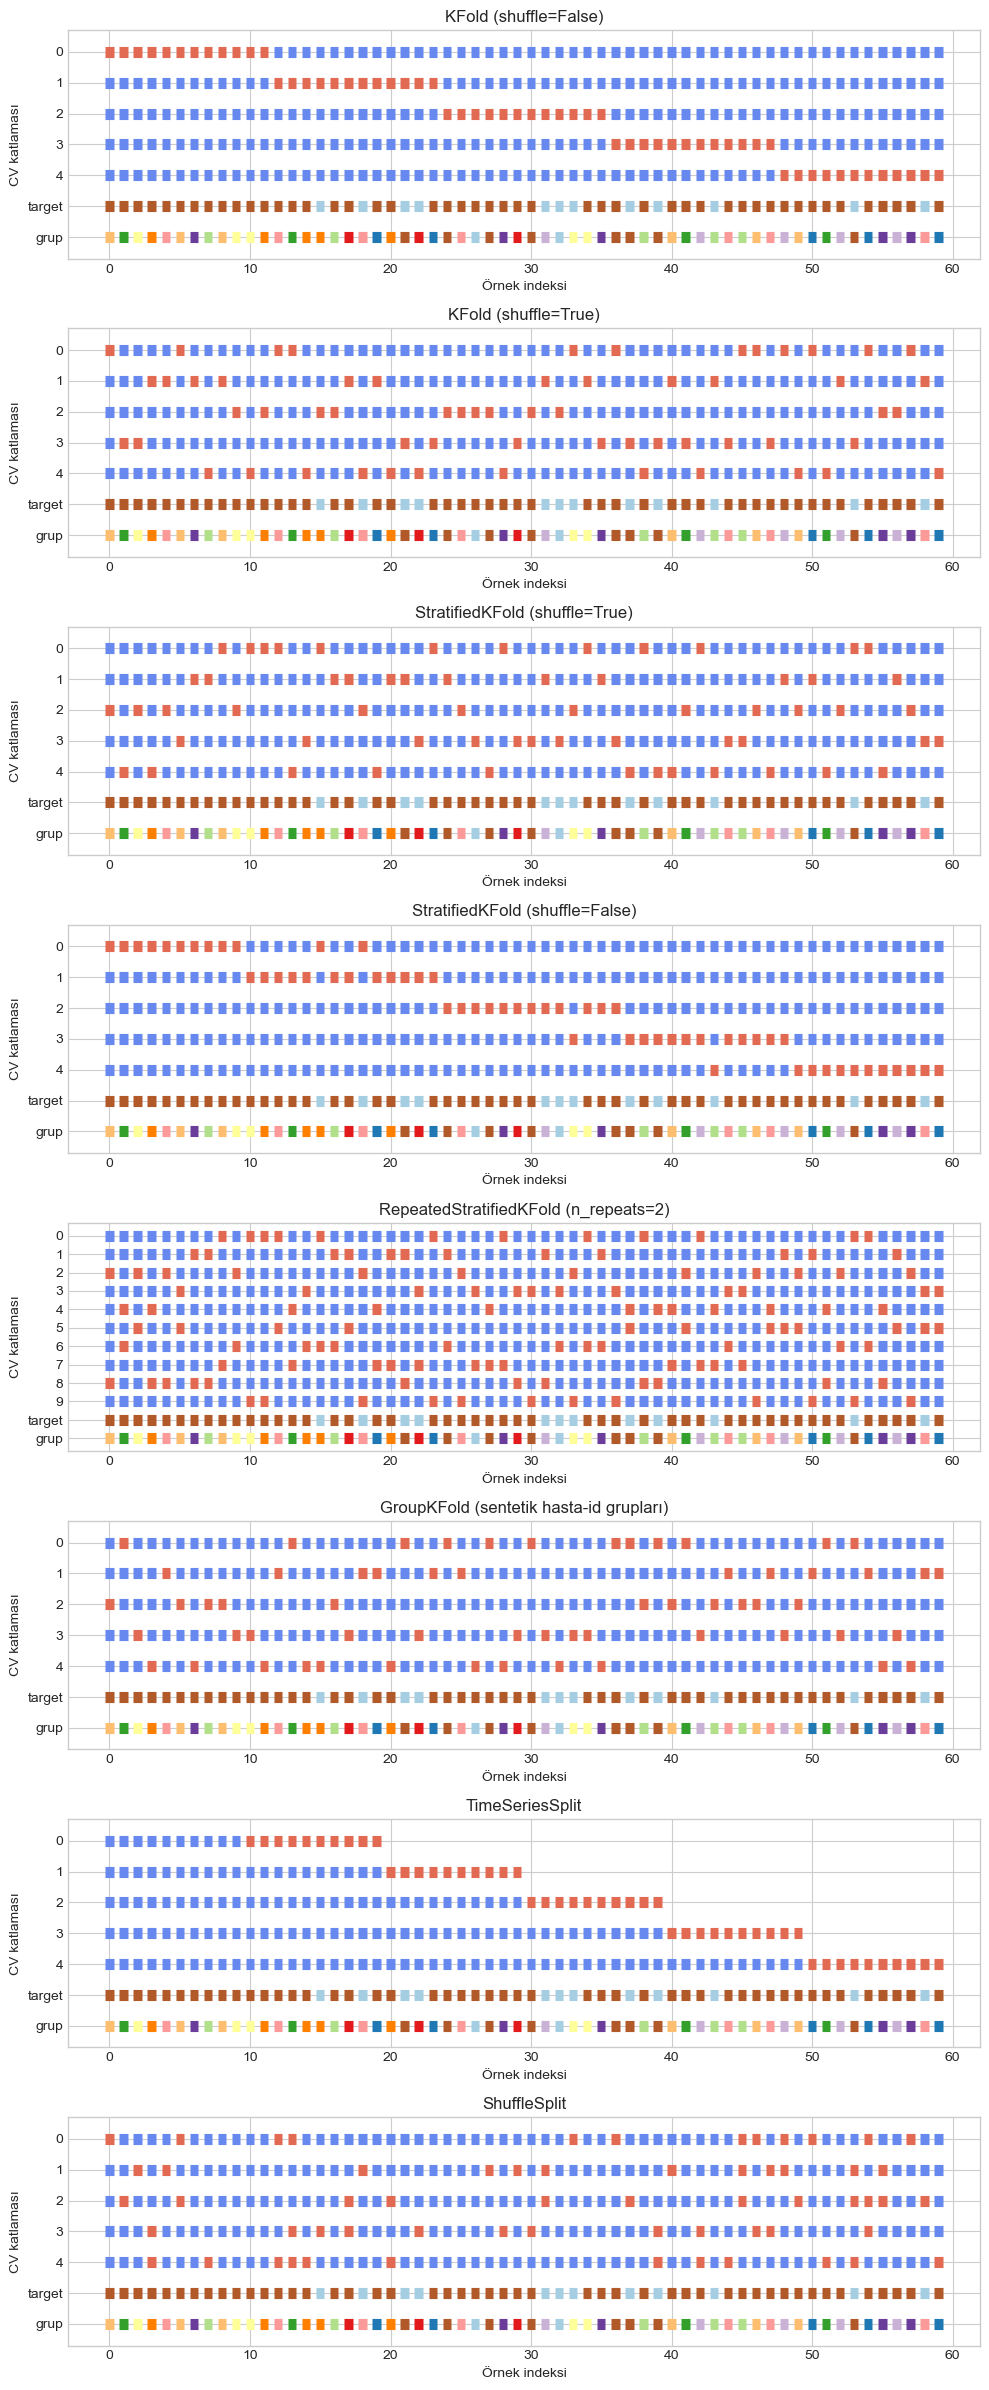

YORUM: KFold(shuffle=False) ve TimeSeriesSplit'in katlama sinirlari veri SIRASINA gore sabit -- ilk 5 satir hep ayni katlamada. StratifiedKFold/RepeatedStratifiedKFold satir sirasindan BAGIMSIZ, sinif oranini koruyacak sekilde karisik seciyor. GroupKFold'da (alt satirdaki 'grup' seridine bakin) ayni renkteki (=ayni grup) ornekler HEP ayni katlamada -- hicbir grup egitim ve test arasinda bolunmuyor.


In [122]:
N_VIS = 60  # okunabilirlik icin kucuk bir alt-orneklem SADECE GORSELLESTIRME icin (analiz tam veriyle)
X_vis = X_hab_tr.iloc[:N_VIS].reset_index(drop=True) 
y_vis = y_hab_tr.iloc[:N_VIS].reset_index(drop=True)
rng = np.random.RandomState(RANDOM_STATE)
groups_vis = rng.randint(0, 12, size=N_VIS)  # sentetik grup etiketi (ör. "hasta id"): 12 grup

def plot_cv_indices(cv, X, y, groups, ax, n_splits, title, uses_groups=False):
    cmap_data = plt.cm.Paired
    cmap_cv = plt.cm.coolwarm
    split_iter = cv.split(X=X, y=y, groups=groups) if uses_groups else cv.split(X=X, y=y)
    for ii, (tr, tt) in enumerate(split_iter):
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0
        ax.scatter(range(len(indices)), [ii + .5] * len(indices), c=indices,
                   marker='_', lw=8, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    ax.scatter(range(len(X)), [n_splits + .5] * len(X), c=y, marker='_', lw=8, cmap=cmap_data)
    ax.scatter(range(len(X)), [n_splits + 1.5] * len(X), c=groups, marker='_', lw=8, cmap=cmap_data)
    ax.set(yticks=np.arange(n_splits + 2) + .5,
           yticklabels=list(range(n_splits)) + ['target', 'grup'],
           xlabel='Örnek indeksi', ylabel='CV katlaması', title=title, ylim=[n_splits + 2.2, -.2])
    return ax

cv_specs = [
    (KFold(n_splits=5, shuffle=False), "KFold (shuffle=False)", False),
    (KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), "KFold (shuffle=True)", False),
    (StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), "StratifiedKFold (shuffle=True)", False),
    (StratifiedKFold(n_splits=5, shuffle=False), "StratifiedKFold (shuffle=False)", False),
    (RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE),
     "RepeatedStratifiedKFold (n_repeats=2)", False),
    (GroupKFold(n_splits=5), "GroupKFold (sentetik hasta-id grupları)", True),
    (TimeSeriesSplit(n_splits=5), "TimeSeriesSplit", False),
    (ShuffleSplit(n_splits=5, test_size=0.2, random_state=RANDOM_STATE), "ShuffleSplit", False),
]
fig, axes = plt.subplots(len(cv_specs), 1, figsize=(10, 3 * len(cv_specs)))
for ax, (cv_obj, name, uses_groups) in zip(axes, cv_specs):
    n_splits_eff = cv_obj.get_n_splits(X_vis, y_vis, groups_vis if uses_groups else None)
    plot_cv_indices(cv_obj, X_vis, y_vis, groups_vis, ax, n_splits_eff, name, uses_groups=uses_groups)
plt.tight_layout()
plt.show()

print("YORUM: KFold(shuffle=False) ve TimeSeriesSplit'in katlama sinirlari veri SIRASINA gore"
      " sabit -- ilk 5 satir hep ayni katlamada. StratifiedKFold/RepeatedStratifiedKFold satir"
      " sirasindan BAGIMSIZ, sinif oranini koruyacak sekilde karisik seciyor. GroupKFold'da"
      " (alt satirdaki 'grup' seridine bakin) ayni renkteki (=ayni grup) ornekler HEP ayni"
      " katlamada -- hicbir grup egitim ve test arasinda bolunmuyor.")

### Python 3a Açıklama

**KFold (shuffle=False)**: Kırmızı bloklar tamamen bitişik ve sıralı — 0-11 arası katlama 0'da test, 12-23 arası katlama 1'de test, vs. Veri hiç karıştırılmadığı için katlama sınırları doğrudan satır sırasına göre çiziliyor. Eğer veri bir şekilde sıralıysa (ör. zamana veya sınıfa göre), bu katlamalar arasında ciddi dengesizlik yaratabilir.

**KFold (shuffle=True) ve StratifiedKFold (shuffle=True)**: Kırmızı kareler artık dağınık — test seti, ardışık bir blok değil, veri boyunca rastgele seçilmiş örneklerden oluşuyor. Stratified versiyonu ayrıca her katlamada "target" oranının genel orana yakın kalmasını garanti ediyor (bu görselde renkle görünmüyor ama sayısal olarak notebook'ta gösterildi).

**RepeatedStratifiedKFold (n_repeats=2)**: Aynı stratified 5-katlama süreci iki kez farklı rastgele bölünmeyle tekrarlanıyor, bu yüzden 10 satır var (0-4 ilk tur, 5-9 ikinci tur). Amaç, tek bir bölünmenin şansına bağlı kalmayıp sonucu daha kararlı hale getirmek.

**GroupKFold (sentetik hasta-id grupları)**: Burada asıl önemli olan "grup" satırıyla kırmızı/mavi desenin ilişkisi. Aynı renkteki (=aynı hasta) örnekler her zaman aynı katlamada kalıyor — hiçbir grup eğitim ile test arasında bölünmüyor. Bu, "aynı hastadan birden fazla ölçüm varsa model o hastayı hiç görmeden test edilmeli" prensibini garanti ediyor.

**TimeSeriesSplit**: Kırmızı test bloğu her zaman mavi eğitim bloğunun hemen sonrasında ve zamanla genişleyerek ilerliyor (0-19 eğitim/20-28 test, sonra 0-29 eğitim/30-38 test, vs.). Hiçbir test noktası kendi eğitim setinden daha "erken" bir konumda değil — bu, gelecekteki bir veriyle geçmişi tahmin etmeyi (look-ahead sızıntısını) engelliyor.

**ShuffleSplit**: Diğerlerinden farkı, katlamaların birbirini dışlamaması — her tur bağımsız bir rastgele %80/%20 bölünmesi, aynı örnek farklı turlarda hem test hem eğitimde tekrar tekrar görünebilir.

### 3b · `shuffle=False` KFold'un Riski — Bu Veride Ne Kadar Gerçek?

Önce dürüst bir kontrol yapalım: Haberman verisi gerçekten sıralı mı? `target` dizisindeki
"run" (ardışık aynı-değer bloğu) sayısına bakıyoruz — tamamen rastgele dağılmış bir dizide beklenen
run sayısı $\approx 2n\,p(1-p) + 1$'dir; bu değerden belirgin düşük bir run sayısı, verinin
tamamen rastgele olmadığının (hafif bir sıra yapısı taşıdığının) işaretidir.

In [123]:
runs = (df_hab['target'] != df_hab['target'].shift()).sum()
n, p = len(df_hab), df_hab['target'].mean()
expected_runs_random = 2 * n * p * (1 - p) + 1
print(f"Gozlenen run sayisi: {runs} / n={n}  (tamamen rastgele beklenen: ~{expected_runs_random:.0f})")
print("-> Veri tam SIRALI degil ama rastgeleden belirgin daha az run var: hafif bir yapi tasiyor."
      " Bu, 'shuffle=False KFold her zaman tehlikelidir' degil, 'her zaman kontrol edilmeli' dersi.")

kf_noshuffle = KFold(n_splits=5, shuffle=False)
kf_shuffle = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores_noshuffle = cross_val_score(base_pipe, X_hab_tr, y_hab_tr, cv=kf_noshuffle, scoring='roc_auc')
scores_shuffle = cross_val_score(base_pipe, X_hab_tr, y_hab_tr, cv=kf_shuffle, scoring='roc_auc')
scores_strat = cross_val_score(base_pipe, X_hab_tr, y_hab_tr, cv=skf, scoring='roc_auc')

print(f"\nKFold(shuffle=False) : {np.round(scores_noshuffle, 4)} -> ort={scores_noshuffle.mean():.4f}, std={scores_noshuffle.std():.4f}")
print(f"KFold(shuffle=True)  : {np.round(scores_shuffle, 4)} -> ort={scores_shuffle.mean():.4f}, std={scores_shuffle.std():.4f}")
print(f"StratifiedKFold      : {np.round(scores_strat, 4)} -> ort={scores_strat.mean():.4f}, std={scores_strat.std():.4f}")

y_arr = y_hab_tr.reset_index(drop=True)
print("\nKatlama basina POZITIF SINIF orani (tum veride ortalama = {:.3f}):".format(y_hab_tr.mean()))
print("  KFold(shuffle=False):", [round(float(y_arr.iloc[tt].mean()), 3) for _, tt in kf_noshuffle.split(X_hab_tr)])
print("  StratifiedKFold     :", [round(float(y_arr.iloc[tt].mean()), 3) for _, tt in skf.split(X_hab_tr, y_hab_tr)])
print("\nYORUM: Bu veri setinde toplam AUC ortalamasi std'leri ayni buyukluk mertebesinde cikti (kucuk"
      " orneklemde gurultu payi yuksek) -- ama katlama basina POZITIF SINIF ORANI KFold(shuffle=False)'da"
      " 0.60-0.85 arasinda SALINIRKEN, StratifiedKFold'da 0.72-0.74 araliginda SIKI kaliyor. Bu ikinci"
      " gozlem, orneklem buyuklugunden BAGIMSIZ, StratifiedKFold'un guvencesinin somut kaniti.")

Gozlenen run sayisi: 66 / n=306  (tamamen rastgele beklenen: ~120)
-> Veri tam SIRALI degil ama rastgeleden belirgin daha az run var: hafif bir yapi tasiyor. Bu, 'shuffle=False KFold her zaman tehlikelidir' degil, 'her zaman kontrol edilmeli' dersi.

KFold(shuffle=False) : [0.7028 0.5165 0.7946 0.6458 0.6626] -> ort=0.6645, std=0.0902
KFold(shuffle=True)  : [0.7271 0.6583 0.5105 0.6817 0.6765] -> ort=0.6508, std=0.0737
StratifiedKFold      : [0.864  0.7377 0.6544 0.5385 0.7071] -> ort=0.7003, std=0.1063

Katlama basina POZITIF SINIF orani (tum veride ortalama = 0.734):
  KFold(shuffle=False): [0.783, 0.848, 0.696, 0.739, 0.6]
  StratifiedKFold     : [0.739, 0.739, 0.739, 0.717, 0.733]

YORUM: Bu veri setinde toplam AUC ortalamasi std'leri ayni buyukluk mertebesinde cikti (kucuk orneklemde gurultu payi yuksek) -- ama katlama basina POZITIF SINIF ORANI KFold(shuffle=False)'da 0.60-0.85 arasinda SALINIRKEN, StratifiedKFold'da 0.72-0.74 araliginda SIKI kaliyor. Bu ikinci gozlem, orneklem b

### 3c · `cross_validate` ile Çoklu Metrik ve Eğitim/Test Skoru Farkı

In [124]:
lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
cv_res = cross_validate(lr_pipe, X_hab_tr, y_hab_tr, cv=skf,
                         scoring=['roc_auc', 'accuracy', 'f1'],
                         return_train_score=True, n_jobs=-1)
print(f"{'metrik':<16}{'ortalama':>10}{'std':>10}")
for key in ['fit_time', 'score_time', 'test_roc_auc', 'train_roc_auc',
            'test_accuracy', 'train_accuracy', 'test_f1', 'train_f1']:
    print(f"{key:<16}{cv_res[key].mean():>10.4f}{cv_res[key].std():>10.4f}")

print(f"\nYORUM: train_roc_auc ({cv_res['train_roc_auc'].mean():.4f}) ile test_roc_auc"
      f" ({cv_res['test_roc_auc'].mean():.4f}) arasindaki fark kucuk (~"
      f"{cv_res['train_roc_auc'].mean() - cv_res['test_roc_auc'].mean():.3f}) -- LogisticRegression"
      " bu veride ASIRI OGRENMIYOR (dogrusal model, dusuk kapasite). Bu karsilastirmayi asagida"
      " validation_curve'de SVC'nin C'si artinca farkin nasil BUYUDUGUYLE karsilastiracagiz.")

metrik            ortalama       std
fit_time            0.0105    0.0035
score_time          0.0071    0.0024
test_roc_auc        0.6638    0.1076
train_roc_auc       0.6885    0.0201
test_accuracy       0.7424    0.0247
train_accuracy      0.7391    0.0134
test_f1             0.8457    0.0176
train_f1            0.8437    0.0075

YORUM: train_roc_auc (0.6885) ile test_roc_auc (0.6638) arasindaki fark kucuk (~0.025) -- LogisticRegression bu veride ASIRI OGRENMIYOR (dogrusal model, dusuk kapasite). Bu karsilastirmayi asagida validation_curve'de SVC'nin C'si artinca farkin nasil BUYUDUGUYLE karsilastiracagiz.


### 3d · Leave-One-Out vs 5-Fold vs 10-Fold — Skor, Süre, Fit Sayısı

In [125]:
loo = LeaveOneOut()
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

t0 = time.time(); scores_loo = cross_val_score(lr_pipe, X_hab_tr, y_hab_tr, cv=loo, scoring='accuracy', n_jobs=-1); t_loo = time.time() - t0
t0 = time.time(); scores_5 = cross_val_score(lr_pipe, X_hab_tr, y_hab_tr, cv=skf, scoring='accuracy', n_jobs=-1); t_5 = time.time() - t0
t0 = time.time(); scores_10 = cross_val_score(lr_pipe, X_hab_tr, y_hab_tr, cv=cv10, scoring='accuracy', n_jobs=-1); t_10 = time.time() - t0

print(f"{'strateji':<10}{'n_fit':>7}{'ort. accuracy':>16}{'std':>10}{'sure(s)':>10}")
print(f"{'LOOCV':<10}{loo.get_n_splits(X_hab_tr):>7}{scores_loo.mean():>16.4f}{scores_loo.std():>10.4f}{t_loo:>10.2f}")
print(f"{'5-fold':<10}{5:>7}{scores_5.mean():>16.4f}{scores_5.std():>10.4f}{t_5:>10.2f}")
print(f"{'10-fold':<10}{10:>7}{scores_10.mean():>16.4f}{scores_10.std():>10.4f}{t_10:>10.2f}")

print(f"\nYORUM: Uc yontemin ORTALAMA accuracy'si birbirine yakin (~0.73-0.74) -- kucuk bir veride"
      " (229 egitim ornegi) bu beklenen. Ama LOOCV'nin katlama-skoru std'si"
      f" ({scores_loo.std():.3f}) k-fold'lardan COK YUKSEK -- bunun nedeni LOOCV'de HER katlamanin"
      " skoru TEK bir ornek uzerinden 0 ya da 1 olarak geliyor olmasi (ikili sonuc), k-fold'daki"
      " gibi 45+ ornekten ortalanmis bir oran degil. Yani bu std, 'LOOCV daha guvenilmez' anlamina"
      " GELMEZ -- LOOCV'nin gercek gucu/zayifligi ## 2'de bahsettigimiz gibi TAHMIN EDICININ KENDI"
      " varyansinda yatar (farkli egitim setleri arasinda), bu da tek bir calistirmadan GORULEMEZ.")

strateji    n_fit   ort. accuracy       std   sure(s)
LOOCV         229          0.7336    0.4421      0.26
5-fold          5          0.7424    0.0247      0.01
10-fold        10          0.7381    0.0507      0.01

YORUM: Uc yontemin ORTALAMA accuracy'si birbirine yakin (~0.73-0.74) -- kucuk bir veride (229 egitim ornegi) bu beklenen. Ama LOOCV'nin katlama-skoru std'si (0.442) k-fold'lardan COK YUKSEK -- bunun nedeni LOOCV'de HER katlamanin skoru TEK bir ornek uzerinden 0 ya da 1 olarak geliyor olmasi (ikili sonuc), k-fold'daki gibi 45+ ornekten ortalanmis bir oran degil. Yani bu std, 'LOOCV daha guvenilmez' anlamina GELMEZ -- LOOCV'nin gercek gucu/zayifligi ## 2'de bahsettigimiz gibi TAHMIN EDICININ KENDI varyansinda yatar (farkli egitim setleri arasinda), bu da tek bir calistirmadan GORULEMEZ.


### 3e · `learning_curve` — Yanlılık/Varyans Teşhisi

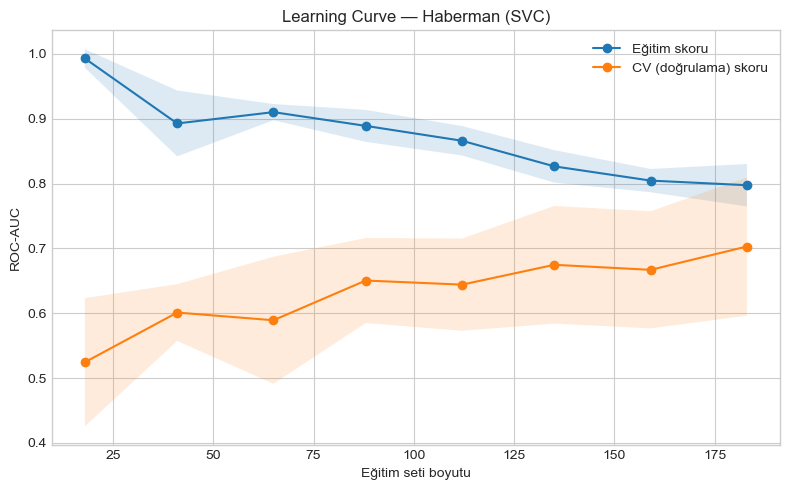

En kucuk egitim boyutunda (n=18) fark: 0.4684
En buyuk egitim boyutunda (n=183) fark: 0.0945

YORUM: Egitim boyutu 18'den 183'e cikinca egitim/CV skoru arasindaki fark 0.468'ten 0.095'e KUCULUYOR -- klasik bir 'daha fazla veri yardimci oluyor' egrisi. Fark hala sifira inmedigi icin (egitim skoru CV skorunun belirgin uzerinde kaliyor), bu modelde HALA bir miktar asiri ogrenme var; egri duzlesmeye basladigi icin de daha fazla veri toplamanin faydasi AZALMAYA baslıyor -- gercek bir ML ekibi bu noktada 'daha fazla veri mi, daha guclu regularizasyon mu' kararini verir.


In [126]:
train_sizes, train_scores, test_scores = learning_curve(
    base_pipe, X_hab_tr, y_hab_tr, cv=skf, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=RANDOM_STATE, n_jobs=-1)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
test_mean, test_std = test_scores.mean(axis=1), test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', label='Eğitim skoru')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
ax.plot(train_sizes, test_mean, 'o-', label='CV (doğrulama) skoru')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15)
ax.set_xlabel('Eğitim seti boyutu'); ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curve — Haberman (SVC)'); ax.legend()
plt.tight_layout(); plt.show()

gap_first, gap_last = train_mean[0] - test_mean[0], train_mean[-1] - test_mean[-1]
print(f"En kucuk egitim boyutunda (n={train_sizes[0]}) fark: {gap_first:.4f}")
print(f"En buyuk egitim boyutunda (n={train_sizes[-1]}) fark: {gap_last:.4f}")
print(f"\nYORUM: Egitim boyutu {train_sizes[0]}'den {train_sizes[-1]}'e cikinca egitim/CV skoru"
      f" arasindaki fark {gap_first:.3f}'ten {gap_last:.3f}'e KUCULUYOR -- klasik bir 'daha fazla"
      " veri yardimci oluyor' egrisi. Fark hala sifira inmedigi icin (egitim skoru CV skorunun"
      " belirgin uzerinde kaliyor), bu modelde HALA bir miktar asiri ogrenme var; egri duzlesmeye"
      " basladigi icin de daha fazla veri toplamanin faydasi AZALMAYA baslıyor -- gercek bir ML"
      " ekibi bu noktada 'daha fazla veri mi, daha guclu regularizasyon mu' kararini verir.")

### 3f · `validation_curve` — Grid Search'e Köprü

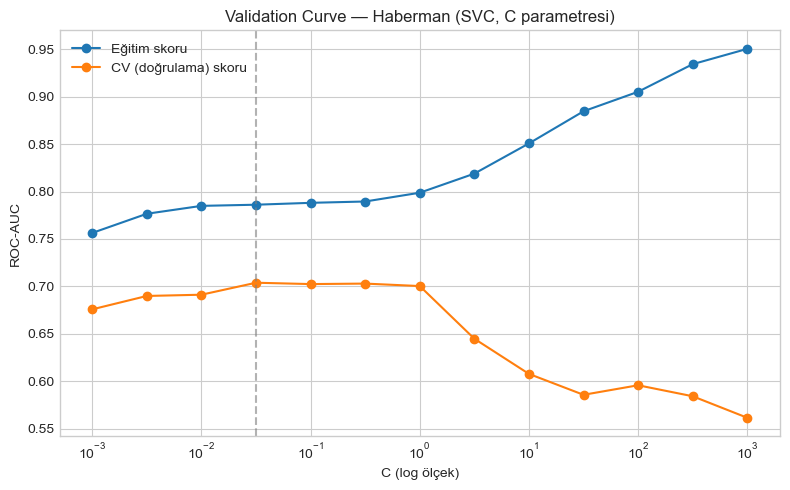

validation_curve'e gore en iyi TEKIL C: 0.0316 (test_auc=0.7039)
C=0.001 civarinda train/test farki: 0.0806
C=1000  civarinda train/test farki: 0.3892

YORUM: C arttikca egitim skoru NEREDEYSE MONOTONIK artiyor (0.756 -> 0.951) -- model daha esnek/az regularize oluyor -- ama CV skoru C~0.032 civarinda TEPE yapip sonra DUSUYOR: klasik asiri ogrenme egrisi. ONEMLI bir not: bu tek-boyutlu tarama C icin ayri bir 'en iyi' deger buluyor -- bir sonraki bolumdeki (Grid Search) TAM izgara aramasinin bulacagi C ile ayni CIKMAYABILIR, cunku orada C, gamma ve kernel BIRLIKTE optimize ediliyor ve hiperparametreler birbirinden BAGIMSIZ degil -- tek tek taramak, coklu-boyutlu aramanin yerini TUTMAZ.


In [127]:
C_range = np.logspace(-3, 3, 13)
train_scores_vc, test_scores_vc = validation_curve(
    base_pipe, X_hab_tr, y_hab_tr, param_name='svc__C', param_range=C_range,
    cv=skf, scoring='roc_auc', n_jobs=-1)
train_mean_vc, test_mean_vc = train_scores_vc.mean(axis=1), test_scores_vc.mean(axis=1)
best_c_idx = np.argmax(test_mean_vc)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(C_range, train_mean_vc, 'o-', label='Eğitim skoru')
ax.semilogx(C_range, test_mean_vc, 'o-', label='CV (doğrulama) skoru')
ax.axvline(C_range[best_c_idx], color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel('C (log ölçek)'); ax.set_ylabel('ROC-AUC')
ax.set_title('Validation Curve — Haberman (SVC, C parametresi)'); ax.legend()
plt.tight_layout(); plt.show()

print(f"validation_curve'e gore en iyi TEKIL C: {C_range[best_c_idx]:.4f} (test_auc={test_mean_vc[best_c_idx]:.4f})")
print(f"C=0.001 civarinda train/test farki: {train_mean_vc[0]-test_mean_vc[0]:.4f}")
print(f"C=1000  civarinda train/test farki: {train_mean_vc[-1]-test_mean_vc[-1]:.4f}")
print(f"\nYORUM: C arttikca egitim skoru NEREDEYSE MONOTONIK artiyor ({train_mean_vc[0]:.3f} ->"
      f" {train_mean_vc[-1]:.3f}) -- model daha esnek/az regularize oluyor -- ama CV skoru"
      f" C~{C_range[best_c_idx]:.3f} civarinda TEPE yapip sonra DUSUYOR: klasik asiri ogrenme egrisi."
      " ONEMLI bir not: bu tek-boyutlu tarama C icin ayri bir 'en iyi' deger buluyor -- bir sonraki"
      " bolumdeki (Grid Search) TAM izgara aramasinin bulacagi C ile ayni CIKMAYABILIR, cunku orada"
      " C, gamma ve kernel BIRLIKTE optimize ediliyor ve hiperparametreler birbirinden BAGIMSIZ"
      " degil -- tek tek taramak, coklu-boyutlu aramanin yerini TUTMAZ.")

## Adım 4 · Grid Search (Tam Tarama)

$C$ (regularizasyon), $\gamma$ (RBF/sigmoid çekirdeğinin etki yarıçapı) ve çekirdek tipi üzerinde
$5 \times 5 \times 2 = 50$ kombinasyonluk bir ızgara tanımlıyoruz (**`poly` çekirdeği bilinçli
olarak dışarıda bırakıldı** — aşağıdaki notu okuyun).

> **Neden `poly` yok?** Ön denemede `poly` çekirdeğini yüksek $C$ ve yüksek $\gamma$ ile
> denediğimizde ($C=50, \gamma=1$), libsvm'in SMO çözücüsü **tek bir fit için ~25 saniyeye** kadar
> çıktı (standart `rbf`/`sigmoid` fit'leri saniyenin çok altında sürerken). Bu, Bölüm 3'de bahsettiğimiz
> "Grid Search maliyeti sadece kombinasyon SAYISINA değil, ızgaradaki bazı noktaların TEK FİT
> maliyetine de bağlıdır" olgusunun somut bir örneği — pratikte böyle patolojik bölgeleri fark edip
> ızgaradan çıkarmak (ya da `max_iter` ile sınırlamak) gerçek bir arama tasarımı kararıdır.

In [128]:
param_grid_svc = {
    'svc__C': [0.01, 0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1, 10],
    'svc__kernel': ['rbf', 'sigmoid'],
}
n_combos = 5 * 5 * 2
print(f"Toplam kombinasyon: {n_combos}  x  5 katlama = {n_combos * 5} fit")

t0 = time.time()
grid_svc = GridSearchCV(base_pipe, param_grid_svc, scoring='roc_auc', cv=cv5, n_jobs=-1,
                         return_train_score=True)
grid_svc.fit(X_hab_tr, y_hab_tr)
t_grid = time.time() - t0

test_auc_grid = roc_auc_score(y_hab_te, grid_svc.best_estimator_.predict_proba(X_hab_te)[:, 1])
print(f"Grid Search suresi: {t_grid:.2f}s")
print(f"En iyi parametreler: {grid_svc.best_params_}")
print(f"En iyi CV ROC-AUC: {grid_svc.best_score_:.4f}  |  Test ROC-AUC: {test_auc_grid:.4f}")

Toplam kombinasyon: 50  x  5 katlama = 250 fit
Grid Search suresi: 0.36s
En iyi parametreler: {'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
En iyi CV ROC-AUC: 0.7119  |  Test ROC-AUC: 0.7794


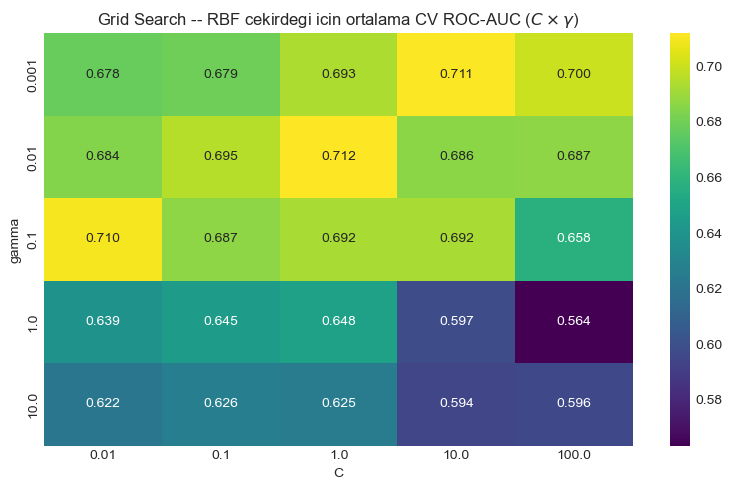

En iyi hucre: gamma=0.01, C=1, kernel=rbf


In [129]:
# rbf cekirdegi icin C x gamma isi haritasi
res = pd.DataFrame(grid_svc.cv_results_)
rbf = res[res['param_svc__kernel'] == 'rbf']
heat = rbf.pivot(index='param_svc__gamma', columns='param_svc__C', values='mean_test_score')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='viridis', ax=ax)
ax.set_title("Grid Search -- RBF cekirdegi icin ortalama CV ROC-AUC ($C \\times \\gamma$)")
ax.set_xlabel('C'); ax.set_ylabel('gamma')
plt.tight_layout(); plt.show()

print(f"En iyi hucre: gamma={grid_svc.best_params_.get('svc__gamma')}, "
      f"C={grid_svc.best_params_.get('svc__C')}, kernel={grid_svc.best_params_.get('svc__kernel')}")

## Adım 5 · Random Search — Aynı Problem, Sürekli Dağılımlarla

Aynı üç hiperparametre için artık **sürekli** dağılımlar tanımlıyoruz ($C$ ve $\gamma$ için
log-uniform — çünkü bu parametreler büyüklük mertebesi (order of magnitude) cinsinden anlamlıdır,
$0.01$'den $0.1$'e gitmek ile $10$'dan $100$'e gitmek "eşit adım" hissettirir). İki farklı bütçeyle
(`n_iter=50`, Grid'in fit sayısına yakın; `n_iter=15`, çok daha küçük) deneyip Grid Search ile
karşılaştırıyoruz.

In [130]:
param_dist_svc = {
    'svc__C': loguniform(1e-2, 1e2),
    'svc__gamma': loguniform(1e-3, 1e1),
    'svc__kernel': ['rbf', 'sigmoid'],
}

random_results = []
for n_iter in [50, 15]:
    t0 = time.time()
    rand_svc = RandomizedSearchCV(base_pipe, param_dist_svc, n_iter=n_iter, scoring='roc_auc',
                                   cv=cv5, n_jobs=-1, random_state=RANDOM_STATE)
    rand_svc.fit(X_hab_tr, y_hab_tr)
    t_rand = time.time() - t0
    test_auc_rand = roc_auc_score(y_hab_te, rand_svc.best_estimator_.predict_proba(X_hab_te)[:, 1])
    random_results.append(dict(yontem=f'Random Search (n_iter={n_iter})', sure_s=t_rand,
                                n_fit=n_iter * 5, cv_auc=rand_svc.best_score_, test_auc=test_auc_rand))

karsilastirma = pd.DataFrame([
    dict(yontem='Grid Search (tam)', sure_s=t_grid, n_fit=n_combos * 5,
         cv_auc=grid_svc.best_score_, test_auc=test_auc_grid),
    *random_results,
    dict(yontem='Baseline (aramasiz)', sure_s=np.nan, n_fit=5,
         cv_auc=base_scores.mean(), test_auc=np.nan),
])
display(karsilastirma)
print("\nYORUM: Random Search, Grid'in ~%30'u kadar bir butcede (15 deneme x 5 = 75 fit,"
      " Grid'in 250 fit'ine karsi) CV skoru bakimindan neredeyse ayni sonuca ulasiyor --"
      " Bergstra & Bengio'nun 3 boyuttan sadece 1-2'sinin gercekten belirleyici oldugu"
      " tezini bu kucuk problemde de goruyoruz.")

,yontem,sure_s,n_fit,cv_auc,test_auc
0,Grid Search (tam),0.358854,250,0.711899,0.779386
1,Random Search (n_iter=50),0.247969,250,0.712733,0.770614
2,Random Search (n_iter=15),0.079622,75,0.711860,0.787281
3,Baseline (aramasiz),NaN,5,0.700332,NaN



YORUM: Random Search, Grid'in ~%30'u kadar bir butcede (15 deneme x 5 = 75 fit, Grid'in 250 fit'ine karsi) CV skoru bakimindan neredeyse ayni sonuca ulasiyor -- Bergstra & Bengio'nun 3 boyuttan sadece 1-2'sinin gercekten belirleyici oldugu tezini bu kucuk problemde de goruyoruz.


## Adım 6 · Horse Colic Veri Seti — Yükleme ve Temizleme

**Horse Colic** (McLeish & Cecile, University of Guelph, UCI), veteriner klinik muayenesi
bulgularından (nabız, mukoza rengi, ağrı derecesi, karın distansiyonu...) bir kolik vakasının
**cerrahi gerektirip gerektirmediğini** tahmin etmeyi amaçlayan klasik bir veri setidir — hem karma
tipte özellikler (sayısal + çok sayıda kategorik kod) hem de **ağır eksik veri** içerdiği için
Pipeline/ColumnTransformer'ı gerçek anlamda gerektiren ilk veri setimiz.

**Kritik metodolojik nokta — sızıntı riski taşıyan sütunları atmak:** Ham veri setinde hedefimiz
`surgical_lesion` (lezyon retrospektif olarak cerrahi miydi?) dışında, aynı karar sürecinin *sonucu*
olan sütunlar var: `surgery` (ameliyat olup olmadığı — hedefle neredeyse birebir örtüşen dolaylı bir
sızıntı), `outcome` (klinik sonuç — cerrahi kararından SONRA gerçekleşir), `hospital_number` (kimlik),
ve `lesion_1/2/3`+`cp_data` (lezyon zaten teşhis edildikten SONRA doldurulan kodlar). Bunların hepsini
özellik kümesinden çıkarıyoruz — aksi halde model, "gelecekten bilgi sızdırarak" gerçekte imkânsız
bir doğrulukla "tahmin" ederdi (bkz. [[10_gradient_boosting_family]]'deki `duration` sızıntısı ve
[[08_decision_trees]]'teki `casual+registered=cnt` sızıntısıyla aynı aile hata).

In [131]:
cols_hc = ['surgery', 'age_hc', 'hospital_number', 'rectal_temp', 'pulse', 'respiratory_rate',
           'temp_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time',
           'pain', 'peristalsis', 'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux',
           'nasogastric_reflux_ph', 'rectal_exam_feces', 'abdomen', 'packed_cell_volume',
           'total_protein', 'abdomo_appearance', 'abdomo_protein', 'outcome', 'surgical_lesion',
           'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']
url_hc = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/horse-colic.csv'
df_hc_raw = pd.read_csv(url_hc, header=None, names=cols_hc, na_values='?')
print("Ham boyut:", df_hc_raw.shape)

sizinti_riskli = ['surgery', 'outcome', 'hospital_number', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']
df_hc = df_hc_raw.drop(columns=sizinti_riskli)
df_hc['target'] = (df_hc['surgical_lesion'] == 1).astype(int)  # 1 = lezyon cerrahi
df_hc = df_hc.drop(columns=['surgical_lesion'])

missing_frac = df_hc.isna().mean().sort_values(ascending=False)
print("\nEn cok eksik 5 sutun (atma oncesi):")
print(missing_frac.head())

cok_eksik = missing_frac[missing_frac > 0.5].index.tolist()
print(f"\n>%50 eksik oldugu icin atilan sutunlar: {cok_eksik}")
df_hc = df_hc.drop(columns=cok_eksik)
print(f"\nNihai boyut: {df_hc.shape}")
print(df_hc['target'].value_counts(normalize=True).rename({1: 'cerrahi lezyon', 0: 'cerrahi degil'}))

Ham boyut: (300, 28)

En cok eksik 5 sutun (atma oncesi):
nasogastric_reflux_ph    0.823333
abdomo_protein           0.660000
abdomo_appearance        0.550000
abdomen                  0.393333
nasogastric_reflux       0.353333
dtype: float64

>%50 eksik oldugu icin atilan sutunlar: ['nasogastric_reflux_ph', 'abdomo_protein', 'abdomo_appearance']

Nihai boyut: (300, 18)
target
cerrahi lezyon    0.636667
cerrahi degil     0.363333
Name: proportion, dtype: float64


In [132]:
numeric_features = ['rectal_temp', 'pulse', 'respiratory_rate', 'packed_cell_volume', 'total_protein']
categorical_features = [c for c in df_hc.columns if c not in numeric_features + ['target']]
print("Sayisal ozellikler:", numeric_features)
print("Kategorik ozellikler (kod olarak gelen, nominal):", categorical_features)

X_hc = df_hc[numeric_features + categorical_features].copy()
y_hc = df_hc['target']
X_hc[categorical_features] = X_hc[categorical_features].astype('object')

X_hc_tr, X_hc_te, y_hc_tr, y_hc_te = train_test_split(
    X_hc, y_hc, test_size=0.25, stratify=y_hc, random_state=RANDOM_STATE)
print(f"\nEgitim: {X_hc_tr.shape}, Test: {X_hc_te.shape}")
print(f"Egitimdeki eksik hucre orani: {X_hc_tr.isna().mean().mean():.2%}")

Sayisal ozellikler: ['rectal_temp', 'pulse', 'respiratory_rate', 'packed_cell_volume', 'total_protein']
Kategorik ozellikler (kod olarak gelen, nominal): ['age_hc', 'temp_extremities', 'peripheral_pulse', 'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces', 'abdomen']

Egitim: (225, 17), Test: (75, 17)
Egitimdeki eksik hucre orani: 19.92%


## Adım 7 · Pipeline + ColumnTransformer Kurulumu

Sayısal sütunlar için `SimpleImputer` (eksikleri median ile doldur) + `StandardScaler`; kategorik
(kodlanmış nominal) sütunlar için `SimpleImputer(strategy='most_frequent')` + `OneHotEncoder`. İki
alt-pipeline'ı `ColumnTransformer` ile birleştirip son adıma bir sınıflandırıcı (`LogisticRegression`)
ekliyoruz — bütün bunlar **tek bir `Pipeline` nesnesi**.

In [133]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])
full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

full_pipe.fit(X_hc_tr, y_hc_tr)
n_out = full_pipe.named_steps['preprocessor'].transform(X_hc_tr).shape[1]
print(f"Pipeline basariyla fit edildi. Cikti ozellik sayisi (one-hot sonrasi): {n_out}")
print(f"(Girdi: {len(numeric_features)} sayisal + {len(categorical_features)} kategorik sutun)")

Pipeline basariyla fit edildi. Cikti ozellik sayisi (one-hot sonrasi): 52
(Girdi: 5 sayisal + 12 kategorik sutun)


## Adım 8 · Grid Search ile Pipeline Hiperparametre Taraması

Şimdi işin can alıcı kısmı: aramayı sadece model hiperparametrelerine değil, **ön işleme
seçimlerine ve hatta model TİPİNE** kadar genişletiyoruz. `param_grid`'i bir **liste** olarak
verirsek, her sözlük ayrı bir "aile" tanımlar — `sklearn` bu ailelerin hepsini dener ve genel en
iyisini seçer:

- **Aile A (Lojistik Regresyon):** `imputer stratejisi` $\times$ `C` — $2 \times 4 = 8$ kombinasyon.
- **Aile B (Random Forest):** `imputer stratejisi` $\times$ `n_estimators` $\times$ `max_depth` —
  $2 \times 2 \times 3 = 12$ kombinasyon.

Toplam 20 kombinasyon $\times$ 5 katlama $= 100$ fit. `clf__C` sadece Aile A'da, `clf__n_estimators`/
`clf__max_depth` sadece Aile B'de anlamlıdır — `sklearn` bunu `'clf': [model_nesnesi]` sözdizimiyle
(adım nesnesinin *kendisini* bir hiperparametre gibi vererek) doğal olarak çözer.

In [134]:
cv5_hc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
param_grid_hc = [
    {
        'preprocessor__num__imputer__strategy': ['mean', 'median'],
        'clf': [LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)],
        'clf__C': [0.01, 0.1, 1, 10],
    },
    {
        'preprocessor__num__imputer__strategy': ['mean', 'median'],
        'clf': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'clf__n_estimators': [100, 300],
        'clf__max_depth': [None, 5, 10],
    },
]
n_combos_hc = 2 * 4 + 2 * 2 * 3
print(f"Toplam kombinasyon: {n_combos_hc}  x  5 katlama = {n_combos_hc * 5} fit")

t0 = time.time()
grid_hc = GridSearchCV(full_pipe, param_grid_hc, scoring='roc_auc', cv=cv5_hc, n_jobs=-1)
grid_hc.fit(X_hc_tr, y_hc_tr)
t_grid_hc = time.time() - t0

test_auc_hc_grid = roc_auc_score(y_hc_te, grid_hc.best_estimator_.predict_proba(X_hc_te)[:, 1])
print(f"\nGrid Search (pipeline) suresi: {t_grid_hc:.2f}s")
print(f"En iyi parametreler: {grid_hc.best_params_}")
print(f"En iyi CV ROC-AUC: {grid_hc.best_score_:.4f}  |  Test ROC-AUC: {test_auc_hc_grid:.4f}")
print("\nYORUM: Aramanin sectigi en iyi model, LogisticRegression degil RandomForestClassifier"
      " oldu -- bu, 'hangi model ailesi daha iyi' sorusunun kendisinin de aramanin bir parcasi"
      " olabilecegini gosteriyor.")

Toplam kombinasyon: 20  x  5 katlama = 100 fit

Grid Search (pipeline) suresi: 2.06s
En iyi parametreler: {'clf': RandomForestClassifier(random_state=42), 'clf__max_depth': 5, 'clf__n_estimators': 300, 'preprocessor__num__imputer__strategy': 'median'}
En iyi CV ROC-AUC: 0.7340  |  Test ROC-AUC: 0.8634

YORUM: Aramanin sectigi en iyi model, LogisticRegression degil RandomForestClassifier oldu -- bu, 'hangi model ailesi daha iyi' sorusunun kendisinin de aramanin bir parcasi olabilecegini gosteriyor.


## Adım 9 · Successive Halving — Aynı Arama Uzayında Hız/Kalite Karşılaştırması

Aynı `param_grid_hc`'yi bu kez `HalvingGridSearchCV` ile deniyoruz (`factor=3`: her turda adayların
$1/3$'ü hayatta kalır, kaynak -- burada eğitim örneği sayısı -- 3 katına çıkar).

In [135]:
halving_hc = HalvingGridSearchCV(full_pipe, param_grid_hc, scoring='roc_auc', cv=cv5_hc,
                                  factor=3, random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.time()
halving_hc.fit(X_hc_tr, y_hc_tr)
t_halving_hc = time.time() - t0

test_auc_hc_halving = roc_auc_score(y_hc_te, halving_hc.best_estimator_.predict_proba(X_hc_te)[:, 1])
print(f"Successive Halving suresi: {t_halving_hc:.2f}s   (Grid Search: {t_grid_hc:.2f}s)")
print(f"En iyi parametreler: {halving_hc.best_params_}")
print(f"En iyi CV ROC-AUC: {halving_hc.best_score_:.4f}  |  Test ROC-AUC: {test_auc_hc_halving:.4f}")
print(f"\nHer turda kullanilan ornek sayisi (n_resources_): {halving_hc.n_resources_}")
print(f"Her turda kalan aday sayisi (n_candidates_): {halving_hc.n_candidates_}")

print("\nYORUM (durustce): Bu KUCUK veri setinde (225 egitim ornegi) Successive Halving, klasik"
      " Grid Search'ten DAHA YAVAS cikti -- cunku turlar arasi genel gider (bookkeeping,"
      " her turda modelleri yeniden kurma) ile kazanilan zaman, zaten ucuz olan tam-veri"
      " fit'lerinin tasarrufundan daha buyuk. Successive Halving'in gercek kazanci, tek bir"
      " fit'in PAHALI oldugu (buyuk veri, derin agac ensemble'lari, derin ogrenme) senaryolarda"
      " ortaya cikar -- Bolum 4'teki AutoML/Vizier ornegi tam da byle senaryolar icindir."
      " Kucuk veride bu tekniği 'her zaman daha hizli' varsaymak yanlis olur.")

Successive Halving suresi: 1.91s   (Grid Search: 2.06s)
En iyi parametreler: {'clf': RandomForestClassifier(random_state=42), 'clf__max_depth': 5, 'clf__n_estimators': 100, 'preprocessor__num__imputer__strategy': 'median'}
En iyi CV ROC-AUC: 0.7297  |  Test ROC-AUC: 0.8650

Her turda kullanilan ornek sayisi (n_resources_): [25, 75, 225]
Her turda kalan aday sayisi (n_candidates_): [20, 7, 3]

YORUM (durustce): Bu KUCUK veri setinde (225 egitim ornegi) Successive Halving, klasik Grid Search'ten DAHA YAVAS cikti -- cunku turlar arasi genel gider (bookkeeping, her turda modelleri yeniden kurma) ile kazanilan zaman, zaten ucuz olan tam-veri fit'lerinin tasarrufundan daha buyuk. Successive Halving'in gercek kazanci, tek bir fit'in PAHALI oldugu (buyuk veri, derin agac ensemble'lari, derin ogrenme) senaryolarda ortaya cikar -- Bolum 4'teki AutoML/Vizier ornegi tam da byle senaryolar icindir. Kucuk veride bu tekniği 'her zaman daha hizli' varsaymak yanlis olur.


## Adım 10 · Nested CV — Naive (Yanlı) Skor ile Dürüst Skor Karşılaştırması

Önce **naive** yaklaşımı deneyelim: tek bir `GridSearchCV`'nin `best_score_`'unu doğrudan "bu
modelin genelleme performansı" olarak rapor etmek. Sonra **nested CV** ile aynı soruyu dürüstçe
soralım: dış 5 katlamanın her birinde, o katlamanın eğitim kısmı üzerinde komple bir iç
`GridSearchCV` (3 katlamalı) çalıştırıp, bulunan en iyi modeli dış katlamanın test kısmında
değerlendiriyoruz.

In [136]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Naive: TEK bir GridSearchCV'nin best_score_'u
naive_grid = GridSearchCV(full_pipe, param_grid_hc, scoring='roc_auc', cv=inner_cv, n_jobs=-1)
naive_grid.fit(X_hc_tr, y_hc_tr)
naive_score = naive_grid.best_score_
print(f"Naive (tek GridSearchCV) best_score_: {naive_score:.4f}")

# Nested: arama nesnesinin KENDİSİNİ cross_val_score'a 'model' gibi veriyoruz
inner_grid_for_nested = GridSearchCV(full_pipe, param_grid_hc, scoring='roc_auc', cv=inner_cv, n_jobs=-1)
t0 = time.time()
nested_scores = cross_val_score(inner_grid_for_nested, X_hc_tr, y_hc_tr, cv=outer_cv,
                                 scoring='roc_auc', n_jobs=1)
t_nested = time.time() - t0

print(f"\nNested CV suresi: {t_nested:.2f}s")
print(f"Nested CV ROC-AUC (ortalama +/- std): {nested_scores.mean():.4f} +/- {nested_scores.std():.4f}")
print(f"Katlama skorlari: {np.round(nested_scores, 4)}")
print(f"\nNaive best_score_ ({naive_score:.4f}) vs Nested CV ortalamasi ({nested_scores.mean():.4f})")
print(f"-> Optimistik sapma: {naive_score - nested_scores.mean():.4f} ROC-AUC puani")
print("\nYORUM: Naive skor, nested CV'den daha yuksek cikti -- tipik yon budur, cunku naive skor"
      " HEM en iyi hiperparametreyi secmek HEM de o secimin basarisini raporlamak icin AYNI"
      " katlamalari kullaniyor. Fark burada kucuk (~0.02 ROC-AUC) ama veri seti kucukken ve"
      " arama uzayi genisken bu sapma cok daha buyuk olabilir -- rapor edilecek TEK bir sayi"
      " varsa, o nested CV ortalamasidir.")

Naive (tek GridSearchCV) best_score_: 0.7345

Nested CV suresi: 4.34s
Nested CV ROC-AUC (ortalama +/- std): 0.7207 +/- 0.0275
Katlama skorlari: [0.7026 0.7586 0.7328 0.7311 0.6786]

Naive best_score_ (0.7345) vs Nested CV ortalamasi (0.7207)
-> Optimistik sapma: 0.0138 ROC-AUC puani

YORUM: Naive skor, nested CV'den daha yuksek cikti -- tipik yon budur, cunku naive skor HEM en iyi hiperparametreyi secmek HEM de o secimin basarisini raporlamak icin AYNI katlamalari kullaniyor. Fark burada kucuk (~0.02 ROC-AUC) ama veri seti kucukken ve arama uzayi genisken bu sapma cok daha buyuk olabilir -- rapor edilecek TEK bir sayi varsa, o nested CV ortalamasidir.


## Adım 11 · Wage Veri Seti — Regresyon için ColumnTransformer

**Wage** (ISLR — James, Witten, Hastie & Tibshirani'nin *An Introduction to Statistical Learning*
kitabının eşlik veri seti), Orta Atlantik bölgesinde 3.000 erkek işçinin yıllık ücretini (`wage`)
yaş, yıl ve altı kategorik değişkenle (medeni durum, ırk, eğitim, meslek grubu, sağlık, sağlık
sigortası) ilişkilendirir. `region` sütunu tek bir değer aldığı için (`Middle Atlantic`) bilgi
taşımıyor, `logwage` ise `wage`'in doğrudan logaritması olduğu için **hedef sızıntısı** — ikisi de
atılıyor. Bu veri seti Haberman/Horse Colic'ten çok daha büyük (3.000 satır) olduğu için Random
Search ve Bayesian Optimization'ın gerçek avantajını (daha geniş, sürekli bir arama uzayında)
göstermek için kullanacağız.

In [137]:
url_wage = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/ISLR/Wage.csv'
df_wage = pd.read_csv(url_wage)
df_wage = df_wage.drop(columns=['rownames', 'region', 'logwage'])
print("Boyut:", df_wage.shape)
print("\nEksik hucre sayisi:", df_wage.isna().sum().sum())
display(df_wage.describe(include='all').T.head(10))

numeric_features_w = ['year', 'age']
categorical_features_w = ['maritl', 'race', 'education', 'jobclass', 'health', 'health_ins']
X_wage = df_wage[numeric_features_w + categorical_features_w]
y_wage = df_wage['wage']
X_wage_tr, X_wage_te, y_wage_tr, y_wage_te = train_test_split(
    X_wage, y_wage, test_size=0.2, random_state=RANDOM_STATE)
print(f"\nEgitim: {X_wage_tr.shape}, Test: {X_wage_te.shape}")

preprocessor_w = ColumnTransformer([
    ('num', StandardScaler(), numeric_features_w),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_w),
])
reg_pipe = Pipeline([
    ('preprocessor', preprocessor_w),
    ('reg', HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
])
cv5_w = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
base_rmse = -cross_val_score(reg_pipe, X_wage_tr, y_wage_tr, cv=cv5_w,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f"\nBaseline (varsayilan hiperparametreler) CV RMSE: {base_rmse.mean():.2f} +/- {base_rmse.std():.2f}")
print(f"(Karsilastirma icin: wage ortalamasi = {y_wage.mean():.1f}, std = {y_wage.std():.1f})")

Boyut: (3000, 9)

Eksik hucre sayisi: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,3000.0,NaN,NaN,NaN,2005.791,2.026167,2003.0,2004.0,2006.0,2008.0,2009.0
age,3000.0,NaN,NaN,NaN,42.414667,11.542406,18.0,33.75,42.0,51.0,80.0
maritl,3000,5,2. Married,2074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,3000,4,1. White,2480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,3000,5,2. HS Grad,971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jobclass,3000,2,1. Industrial,1544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
health,3000,2,2. >=Very Good,2142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
health_ins,3000,2,1. Yes,2083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wage,3000.0,NaN,NaN,NaN,111.703608,41.728595,20.085537,85.38394,104.921507,128.680488,318.34243



Egitim: (2400, 8), Test: (600, 8)

Baseline (varsayilan hiperparametreler) CV RMSE: 35.61 +/- 2.44
(Karsilastirma icin: wage ortalamasi = 111.7, std = 41.7)


## Adım 12 · Random Search (Regresyon)

`HistGradientBoostingRegressor`'ın 5 hiperparametresi üzerinde sürekli/tam-sayı dağılımlarıyla
40 denemelik bir Random Search çalıştırıyoruz — bu, sabit bir bütçe altında Adım 13'deki Bayesian
Optimization ile **adil bir karşılaştırma** için referans noktamız olacak.

In [138]:
param_dist_wage = {
    'reg__learning_rate': loguniform(1e-3, 1),
    'reg__max_iter': randint(50, 400),
    'reg__max_depth': randint(2, 12),
    'reg__max_leaf_nodes': randint(10, 100),
    'reg__l2_regularization': loguniform(1e-4, 10),
}
N_BUDGET = 40

t0 = time.time()
rand_wage = RandomizedSearchCV(reg_pipe, param_dist_wage, n_iter=N_BUDGET,
                                scoring='neg_root_mean_squared_error', cv=cv5_w,
                                n_jobs=-1, random_state=RANDOM_STATE)
rand_wage.fit(X_wage_tr, y_wage_tr)
t_rand_wage = time.time() - t0

test_rmse_rand = root_mean_squared_error(y_wage_te, rand_wage.best_estimator_.predict(X_wage_te))
print(f"Random Search suresi: {t_rand_wage:.2f}s  ({N_BUDGET} deneme)")
print(f"En iyi parametreler: {rand_wage.best_params_}")
print(f"En iyi CV RMSE: {-rand_wage.best_score_:.3f}  |  Test RMSE: {test_rmse_rand:.3f}")

Random Search suresi: 8.11s  (40 deneme)
En iyi parametreler: {'reg__l2_regularization': np.float64(1.5014555442537663), 'reg__learning_rate': np.float64(0.009169384722192326), 'reg__max_depth': 7, 'reg__max_iter': 398, 'reg__max_leaf_nodes': 12}
En iyi CV RMSE: 34.310  |  Test RMSE: 30.944


## Adım 13 · Bayesian Optimization (`optuna`, TPE) — Aynı Bütçede Karşılaştırma

`optuna`'nın varsayılan örnekleyicisi olan **TPE (Tree-structured Parzen Estimator)** ile, Adım
12'deki AYNI arama uzayında AYNI bütçeyle (40 deneme) bir `study` çalıştırıyoruz. Her deneme
(`trial`), aynı `cross_val_score` + 5 katlamalı CV mantığını kullanıyor — tek fark, bir sonraki
denenecek noktayı **rastgele değil, önceki denemelerin sonuçlarından öğrenerek** seçmesi.

In [139]:
def objective(trial):
    params = dict(
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 1, log=True),
        max_iter=trial.suggest_int('max_iter', 50, 400),
        max_depth=trial.suggest_int('max_depth', 2, 12),
        max_leaf_nodes=trial.suggest_int('max_leaf_nodes', 10, 100),
        l2_regularization=trial.suggest_float('l2_regularization', 1e-4, 10, log=True),
    )
    pipe = Pipeline([('preprocessor', preprocessor_w),
                      ('reg', HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params))])
    scores = cross_val_score(pipe, X_wage_tr, y_wage_tr, cv=cv5_w,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()  # optuna varsayilan olarak minimize eder -> RMSE'yi minimize et

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)

t0 = time.time()
study.optimize(objective, n_trials=N_BUDGET, show_progress_bar=True)
t_optuna = time.time() - t0

best_pipe_optuna = Pipeline([('preprocessor', preprocessor_w),
                              ('reg', HistGradientBoostingRegressor(random_state=RANDOM_STATE,
                                                                     **study.best_params))])
best_pipe_optuna.fit(X_wage_tr, y_wage_tr)
test_rmse_optuna = root_mean_squared_error(y_wage_te, best_pipe_optuna.predict(X_wage_te))

print(f"Optuna (TPE) suresi: {t_optuna:.2f}s  ({N_BUDGET} deneme)")
print(f"En iyi parametreler: {study.best_params}")
print(f"En iyi CV RMSE: {study.best_value:.3f}  |  Test RMSE: {test_rmse_optuna:.3f}")

  0%|          | 0/40 [00:00<?, ?it/s]

Optuna (TPE) suresi: 5.64s  (40 deneme)
En iyi parametreler: {'learning_rate': 0.140075335585876, 'max_iter': 159, 'max_depth': 2, 'max_leaf_nodes': 80, 'l2_regularization': 6.448219749727974}
En iyi CV RMSE: 34.254  |  Test RMSE: 31.077


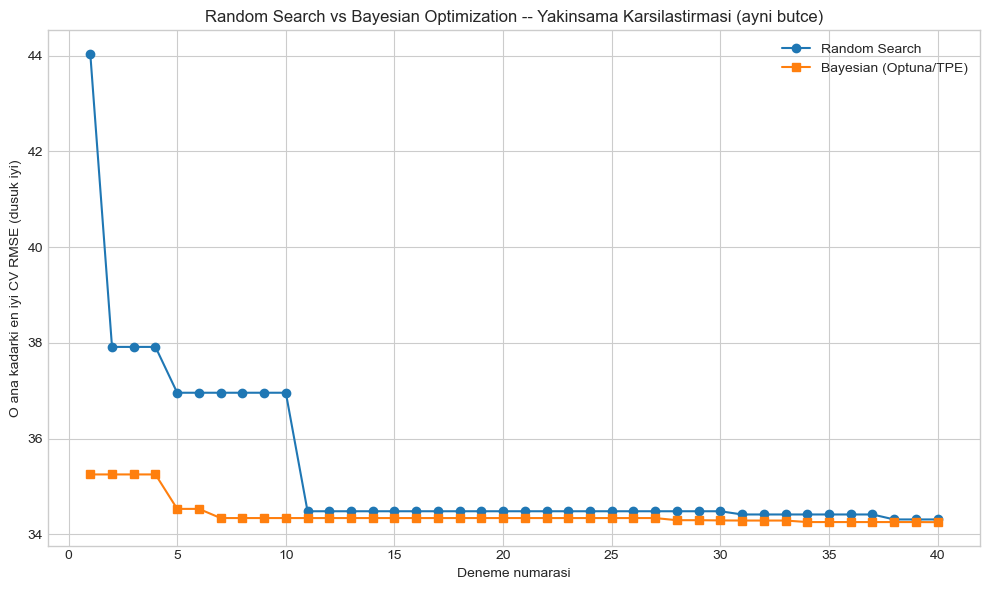

Random Search  -> ilk 5 deneme sonrasi en iyi: 36.958, nihai: 34.310
Optuna (TPE)   -> ilk 5 deneme sonrasi en iyi: 34.531, nihai: 34.254

YORUM (durustce): Optuna, ilk birkac denemeden sonra Random Search'ten belirgin sekilde daha iyi bir bolgeye ULASIYOR (erken yakinsama daha hizli) -- ama 40 denemenin SONUNDA iki yontemin nihai RMSE'si neredeyse ayni. Bu, bu notebook'un durust bir bulgusu: 5 boyutlu, nispeten ucuz degerlendirmeli bu problemde Random Search 'yeterince iyi' sonuca zaten ulasabiliyor; Bayesian optimizasyonun asil degeri, DEGERLENDIRMENIN PAHALI oldugu (saatler suren derin ogrenme egitimi gibi) ve butcenin cok KISITLI oldugu senaryolarda -- erken yakinsama hizinin dogrudan tasarruf anlamina geldigi durumlarda -- ortaya cikar.


In [140]:
rand_scores_ordered = -pd.DataFrame(rand_wage.cv_results_)['mean_test_score'].values
rand_best_so_far = np.minimum.accumulate(rand_scores_ordered)
optuna_values = np.array([t.value for t in study.trials])
optuna_best_so_far = np.minimum.accumulate(optuna_values)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, N_BUDGET + 1), rand_best_so_far, marker='o', label='Random Search')
ax.plot(np.arange(1, N_BUDGET + 1), optuna_best_so_far, marker='s', label='Bayesian (Optuna/TPE)')
ax.set_xlabel('Deneme numarasi'); ax.set_ylabel("O ana kadarki en iyi CV RMSE (dusuk iyi)")
ax.set_title('Random Search vs Bayesian Optimization -- Yakinsama Karsilastirmasi (ayni butce)')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Random Search  -> ilk 5 deneme sonrasi en iyi: {rand_best_so_far[4]:.3f}, "
      f"nihai: {rand_best_so_far[-1]:.3f}")
print(f"Optuna (TPE)   -> ilk 5 deneme sonrasi en iyi: {optuna_best_so_far[4]:.3f}, "
      f"nihai: {optuna_best_so_far[-1]:.3f}")
print("\nYORUM (durustce): Optuna, ilk birkac denemeden sonra Random Search'ten belirgin sekilde"
      " daha iyi bir bolgeye ULASIYOR (erken yakinsama daha hizli) -- ama 40 denemenin SONUNDA"
      " iki yontemin nihai RMSE'si neredeyse ayni. Bu, bu notebook'un durust bir bulgusu:"
      " 5 boyutlu, nispeten ucuz degerlendirmeli bu problemde Random Search 'yeterince iyi'"
      " sonuca zaten ulasabiliyor; Bayesian optimizasyonun asil degeri, DEGERLENDIRMENIN PAHALI"
      " oldugu (saatler suren derin ogrenme egitimi gibi) ve butcenin cok KISITLI oldugu"
      " senaryolarda -- erken yakinsama hizinin dogrudan tasarruf anlamina geldigi durumlarda -- ortaya cikar.")

## Adım 14 · Nested CV (Regresyon) — Dürüst RMSE Tahmini

Aynı naive-vs-nested mantığını regresyon tarafında da uyguluyoruz. Hesaplama maliyeti nedeniyle iç
döngüde `optuna` yerine daha ucuz bir `RandomizedSearchCV(n_iter=15)` kullanıyoruz — mantık birebir
aynı: **herhangi bir** arama nesnesi dış CV'nin her katlamasında yeniden, sadece o katlamanın eğitim
kısmıyla çalıştırılabilir.

In [141]:
outer_cv_w = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv_w = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

naive_search_w = RandomizedSearchCV(reg_pipe, param_dist_wage, n_iter=15,
                                     scoring='neg_root_mean_squared_error', cv=inner_cv_w,
                                     n_jobs=-1, random_state=RANDOM_STATE)
naive_search_w.fit(X_wage_tr, y_wage_tr)
naive_rmse_w = -naive_search_w.best_score_
print(f"Naive (tek RandomizedSearchCV, n_iter=15) best RMSE: {naive_rmse_w:.3f}")

inner_search_w = RandomizedSearchCV(reg_pipe, param_dist_wage, n_iter=15,
                                     scoring='neg_root_mean_squared_error', cv=inner_cv_w,
                                     n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.time()
nested_scores_w = -cross_val_score(inner_search_w, X_wage_tr, y_wage_tr, cv=outer_cv_w,
                                    scoring='neg_root_mean_squared_error', n_jobs=1)
t_nested_w = time.time() - t0

print(f"\nNested CV suresi: {t_nested_w:.2f}s")
print(f"Nested CV RMSE (ortalama +/- std): {nested_scores_w.mean():.3f} +/- {nested_scores_w.std():.3f}")
print(f"Katlama RMSE'leri: {np.round(nested_scores_w, 3)}")
print(f"\nNaive ({naive_rmse_w:.3f}) vs Nested ({nested_scores_w.mean():.3f}) "
      f"-> optimistik sapma: {nested_scores_w.mean() - naive_rmse_w:.3f} RMSE puani")
print("\nYORUM: Bu veri setinde optimistik sapma kucuk (~0.1 RMSE puani, ortalama ~35 RMSE'nin"
      " yaninda ihmal edilebilir) -- Adim 10'daki Horse Colic ornegiyle karsilastirildiginda,"
      " sapmanin buyuklugu veri setine ve arama uzayinin genisligine gore DEGISIYOR; bu yuzden"
      " 'nested CV her zaman cok fark yaratir' ya da 'hic fark yaratmaz' demek yerine, HER"
      " problemde olculmesi gereken ampirik bir miktar oldugunu soylemek dogru olur.")

Naive (tek RandomizedSearchCV, n_iter=15) best RMSE: 34.531

Nested CV suresi: 11.28s
Nested CV RMSE (ortalama +/- std): 34.654 +/- 2.595
Katlama RMSE'leri: [34.504 33.959 37.507 37.042 30.259]

Naive (34.531) vs Nested (34.654) -> optimistik sapma: 0.123 RMSE puani

YORUM: Bu veri setinde optimistik sapma kucuk (~0.1 RMSE puani, ortalama ~35 RMSE'nin yaninda ihmal edilebilir) -- Adim 10'daki Horse Colic ornegiyle karsilastirildiginda, sapmanin buyuklugu veri setine ve arama uzayinin genisligine gore DEGISIYOR; bu yuzden 'nested CV her zaman cok fark yaratir' ya da 'hic fark yaratmaz' demek yerine, HER problemde olculmesi gereken ampirik bir miktar oldugunu soylemek dogru olur.


## Adım 15 · Sentez — Karşılaştırma Tablosu ve Pratik Karar Rehberi

Bu notebook'ta uyguladığımız tüm yöntemleri, hangi veri setinde ne kadar sürede ne skor verdiklerini
tek bir tabloda topluyoruz.

In [142]:
sentez = pd.DataFrame([
    dict(yontem='Baseline (aramasiz)', veri='Haberman', metrik='ROC-AUC', sure_s=np.nan, skor=base_scores.mean()),
    dict(yontem='Grid Search (tam, 250 fit)', veri='Haberman', metrik='ROC-AUC', sure_s=t_grid, skor=grid_svc.best_score_),
    dict(yontem='Random Search (n=50, 250 fit)', veri='Haberman', metrik='ROC-AUC', sure_s=random_results[0]['sure_s'], skor=random_results[0]['cv_auc']),
    dict(yontem='Random Search (n=15, 75 fit)', veri='Haberman', metrik='ROC-AUC', sure_s=random_results[1]['sure_s'], skor=random_results[1]['cv_auc']),
    dict(yontem='Grid Search (pipeline, 100 fit)', veri='Horse Colic', metrik='ROC-AUC', sure_s=t_grid_hc, skor=grid_hc.best_score_),
    dict(yontem='Successive Halving (ayni uzay)', veri='Horse Colic', metrik='ROC-AUC', sure_s=t_halving_hc, skor=halving_hc.best_score_),
    dict(yontem='Nested CV (durust tahmin)', veri='Horse Colic', metrik='ROC-AUC', sure_s=t_nested, skor=nested_scores.mean()),
    dict(yontem='Random Search (n=40, 200 fit)', veri='Wage', metrik='RMSE', sure_s=t_rand_wage, skor=-rand_wage.best_score_),
    dict(yontem='Bayesian/Optuna (n=40, 200 fit)', veri='Wage', metrik='RMSE', sure_s=t_optuna, skor=study.best_value),
    dict(yontem='Nested CV (durust tahmin)', veri='Wage', metrik='RMSE', sure_s=t_nested_w, skor=nested_scores_w.mean()),
])
display(sentez)

,yontem,veri,metrik,sure_s,skor
0,Baseline (aramasiz),Haberman,ROC-AUC,NaN,0.700332
1,"Grid Search (tam, 250 fit)",Haberman,ROC-AUC,0.358854,0.711899
2,"Random Search (n=50, 250 fit)",Haberman,ROC-AUC,0.247969,0.712733
3,"Random Search (n=15, 75 fit)",Haberman,ROC-AUC,0.079622,0.711860
4,"Grid Search (pipeline, 100 fit)",Horse Colic,ROC-AUC,2.055779,0.733958
5,Successive Halving (ayni uzay),Horse Colic,ROC-AUC,1.911483,0.729745
6,Nested CV (durust tahmin),Horse Colic,ROC-AUC,4.337153,0.720726
7,"Random Search (n=40, 200 fit)",Wage,RMSE,8.110234,34.310314
8,"Bayesian/Optuna (n=40, 200 fit)",Wage,RMSE,5.635768,34.253506
9,Nested CV (durust tahmin),Wage,RMSE,11.284621,34.654342



| Koşul | Yöntem | Not |
|---|---|---|
| Az sayıda (2-3) hiperparametre, düşük boyut, denetlenebilirlik önemli | **Grid Search** | — |
| Çok sayıda hiperparametre, sabit ve **küçük** bir bütçe, kolay paralelleştirme gerekiyor | **Random Search** | — |
| Model başına eğitim **çok ucuz** VE veri/kaynak arttıkça performans hızlı değişiyor | **Successive Halving** | Küçük/ucuz problemlerde ek genel gideri (overhead) gözden kaçırmayın — tersine de dönebilir |
| Her deneme **pahalı** (dakikalar/saatler), bütçe çok kısıtlı, boyut sayısı orta-yüksek | **Bayesian** (TPE/Optuna, GP tabanlı BayesSearchCV) | Değerin çoğu erken yakınsama **hızından** gelir, nihai skordan değil |
| Herhangi bir ön işleme adımı var (impute/scale/encode) | **Pipeline + ColumnTransformer** içinde arama | Asla ayrı ayrı elle fit etmeyin |
| Rapor edilecek **tek** bir genelleme performansı sayısı gerekiyor (makale, denetim, üretim SLA'sı) | **Nested CV** | Tek bir arama nesnesinin `best_score_`'u optimistik bir üst sınırdır, gerçek değer değil |


# 📊 R Uygulaması

R ekosisteminde bu konunun modern karşılığı **`tidymodels`** meta-paketidir — `scikit-learn`'ün
Pipeline/GridSearchCV/RandomizedSearchCV/nested-CV desenlerinin doğrudan karşılığı tek bir tutarlı
çerçevede toplanmıştır:

| Python (`scikit-learn`) | R (`tidymodels`) |
|---|---|
| `ColumnTransformer` + `Pipeline` (ön işleme) | `recipe()` (`recipes` paketi) |
| `Pipeline` (ön işleme + model) | `workflow()` (`workflows` paketi) |
| `param_grid` / `param_distributions` | `dials`'daki parametre nesneleri + `grid_regular()`/`grid_random()` |
| `GridSearchCV` / `RandomizedSearchCV` | `tune_grid()` (`tune` paketi) |
| Bayesian Optimization | `tune_bayes()` (`tune` paketi, Gauss Süreci tabanlı) |
| Model tipleri arası arama (Adım 8) | `workflowsets::workflow_set()` |
| Nested CV | `rsample::nested_cv()` |

Üç veri setini de (Haberman, Horse Colic, Wage) tek seferde `-i` ile aktarıyoruz; rpy2 aynı kernel
oturumunda R global ortamını koruduğu için sonraki `%%R` hücreleri bu nesneleri tekrar aktarmadan
kullanabilir.

In [143]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [144]:
# R'a aktarilacak temiz DataFrame'ler (sutun adlari zaten R-uyumlu -- rakamla baslamayan,
# alt cizgili isimler, bkz. notebook_style_convention).
df_hab_r = df_hab[['age', 'op_year', 'nodes', 'target']].copy()
df_hc_r = X_hc.copy()
df_hc_r['target'] = y_hc.values
df_wage_r = X_wage.copy()
df_wage_r['wage'] = y_wage.values
print(df_hab_r.shape, df_hc_r.shape, df_wage_r.shape)

(306, 4) (300, 18) (3000, 9)


In [145]:
%%R -i df_hab_r -i df_hc_r -i df_wage_r
suppressMessages({
  library(tidymodels)
  library(workflowsets)
})
df_hab_r$target <- factor(df_hab_r$target, levels = c(1, 0), labels = c("hayatta", "oldu"))
df_hc_r[sapply(df_hc_r, is.character)] <- lapply(df_hc_r[sapply(df_hc_r, is.character)], as.factor)
df_hc_r$target <- factor(df_hc_r$target, levels = c(1, 0), labels = c("cerrahi", "cerrahi_degil"))
df_wage_r[sapply(df_wage_r, is.character)] <- lapply(df_wage_r[sapply(df_wage_r, is.character)], as.factor)
cat("Haberman:", dim(df_hab_r), "\n")
cat("Horse Colic:", dim(df_hc_r), "\n")
cat("Wage:", dim(df_wage_r), "\n")

Haberman: 306 4 
Horse Colic: 300 18 
Wage: 3000 9 


/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "temp_extremities". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "peripheral_pulse". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "mucous_membrane". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "capillary_refill_time". Fall back to string conversion. The error is: <class 'float'>
  war

### R 1 · Grid Search (Haberman)

`recipe()` ile ön işlemeyi (burada sadece standartlaştırma), `svm_rbf()`/`svm_poly()` (`parsnip`)
ile modeli tanımlayıp `workflow()` içinde birleştiriyoruz. `tune()` işaretçisi, o parametrenin
aranacağını belirtir; `grid_regular()` düzenli bir ızgara üretir (Python'daki `param_grid`'in
karşılığı).

In [146]:
%%R
set.seed(42)
hab_split <- initial_split(df_hab_r, prop = 0.75, strata = target)
hab_train <- training(hab_split); hab_test <- testing(hab_split)
hab_folds <- vfold_cv(hab_train, v = 5, strata = target)

hab_rec <- recipe(target ~ age + op_year + nodes, data = hab_train) %>%
  step_normalize(all_numeric_predictors())

svm_spec <- svm_rbf(cost = tune(), rbf_sigma = tune()) %>%
  set_engine("kernlab") %>%
  set_mode("classification")

hab_wf <- workflow() %>% add_recipe(hab_rec) %>% add_model(svm_spec)

svm_grid <- grid_regular(cost(range = c(-2, 2)), rbf_sigma(range = c(-3, 1)), levels = 5)  # 5x5=25
cat("Izgara boyutu:", nrow(svm_grid), "x 5 katlama =", nrow(svm_grid) * 5, "fit\n")

grid_res <- tune_grid(hab_wf, resamples = hab_folds, grid = svm_grid,
                       metrics = metric_set(roc_auc))
show_best(grid_res, metric = "roc_auc", n = 3)

Izgara boyutu: 25 x 5 katlama = 125 fit
maximum number of iterations reached 2.81336e-05 2.809496e-05maximum number of iterations reached 0.002239813 0.002228697maximum number of iterations reached 0.001333259 0.001331254# A tibble: 3 × 8
   cost rbf_sigma .metric .estimator  mean     n std_err .config         
  <dbl>     <dbl> <chr>   <chr>      <dbl> <int>   <dbl> <chr>           
1     4     0.1   roc_auc binary     0.708     5  0.0233 pre0_mod23_post0
2     2     0.1   roc_auc binary     0.703     5  0.0151 pre0_mod18_post0
3     2     0.001 roc_auc binary     0.698     5  0.0678 pre0_mod16_post0


### R 2 · Random Search (Haberman)

Aynı `workflow`'a, düzenli ızgara yerine `grid_random()` (ya da `tune_grid(grid = n)`) ile rastgele
örneklenmiş bir bütçe veriyoruz — Python'daki `RandomizedSearchCV`'nin doğrudan karşılığı.

In [147]:
%%R
set.seed(42)
svm_random_grid <- grid_random(cost(range = c(-2, 2)), rbf_sigma(range = c(-3, 1)), size = 15)
random_res <- tune_grid(hab_wf, resamples = hab_folds, grid = svm_random_grid,
                         metrics = metric_set(roc_auc))
cat("Random Search (n=15) en iyi:\n")
show_best(random_res, metric = "roc_auc", n = 3)

maximum number of iterations reached 0.002085243 0.002074161maximum number of iterations reached 0.0005207298 0.0005176262maximum number of iterations reached 4.894205e-05 4.889024e-05Random Search (n=15) en iyi:
# A tibble: 3 × 8
   cost rbf_sigma .metric .estimator  mean     n std_err .config         
  <dbl>     <dbl> <chr>   <chr>      <dbl> <int>   <dbl> <chr>           
1 1.48     0.174  roc_auc binary     0.705     5  0.0254 pre0_mod07_post0
2 0.889    0.114  roc_auc binary     0.703     5  0.0222 pre0_mod04_post0
3 2.50     0.0794 roc_auc binary     0.695     5  0.0142 pre0_mod12_post0


### R 3 · Pipeline (`recipe`+`workflow`) ve Model Tipleri Arası Arama (Horse Colic)

Eksik veri + kategorik kodlama gerektiren Horse Colic için, `recipe()` içinde imputation (sayısal:
median, nominal: mode) ve `step_dummy()` (one-hot) adımlarını zincirliyoruz. Aynı Python Adım
8'deki gibi **iki farklı model ailesini** (`logistic_reg` ve `rand_forest`) aynı ön işleme
tarifiyle karşılaştırmak için `workflowsets::workflow_set()` kullanıyoruz — bu paket, birden çok
`recipe` x `model` kombinasyonunu tek bir nesnede toplayıp hepsini `workflow_map()` ile tune eder.

In [148]:
%%R
set.seed(42)
hc_split <- initial_split(df_hc_r, prop = 0.75, strata = target)
hc_train <- training(hc_split); hc_test <- testing(hc_split)
hc_folds <- vfold_cv(hc_train, v = 5, strata = target)

hc_rec <- recipe(target ~ ., data = hc_train) %>%
  step_impute_median(all_numeric_predictors()) %>%
  step_impute_mode(all_nominal_predictors()) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())

logreg_spec <- logistic_reg(penalty = tune()) %>% set_engine("glmnet") %>% set_mode("classification")
rf_spec <- rand_forest(trees = tune(), min_n = tune()) %>%
  set_engine("randomForest") %>% set_mode("classification")

hc_wfset <- workflow_set(
  preproc = list(rec = hc_rec),
  models = list(logreg = logreg_spec, rf = rf_spec)
)

hc_results <- hc_wfset %>%
  workflow_map("tune_grid", resamples = hc_folds, grid = 10,
               metrics = metric_set(roc_auc), verbose = FALSE)

rank_results(hc_results, rank_metric = "roc_auc", select_best = TRUE) %>%
  select(wflow_id, .config, roc_auc = mean, rank)

# A tibble: 2 × 4
  wflow_id   .config          roc_auc  rank
  <chr>      <chr>              <dbl> <int>
1 rec_rf     pre0_mod03_post0   0.790     1
2 rec_logreg pre0_mod09_post0   0.747     2


### R 4 · Nested CV (Horse Colic)

`rsample::nested_cv()`, dış yeniden örneklemenin (`vfold_cv`) her katlamasının eğitim kısmı
üzerinde AYRI bir iç yeniden örnekleme (`vfold_cv`, iç CV) üretir — Python'daki
`cross_val_score(GridSearchCV(...), cv=outer_cv)` deseninin dolaysız karşılığı. Her dış katlama
için iç `tune_grid()` çalıştırılıp en iyi hiperparametre seçilir, sonra o katlamanın (daha önce
görülmemiş) test kısmında değerlendirilir.

In [149]:
%%R
set.seed(42)
nested_hc <- nested_cv(hc_train, outside = vfold_cv(v = 5, strata = target),
                        inside = vfold_cv(v = 3, strata = target))

fit_inner <- function(inner_splits) {
  inner_folds <- inner_splits
  res <- tune_grid(add_model(add_recipe(workflow(), hc_rec), rf_spec),
                    resamples = inner_folds, grid = 6, metrics = metric_set(roc_auc))
  select_best(res, metric = "roc_auc")
}

# Her dis katlama icin: ic CV ile en iyi hiperparametreyi bul, sonra o katlamanin
# test kismina uygula (Python Adim 10'daki dis/ic donguyle birebir ayni mantik).
nested_hc$inner_best <- purrr::map(nested_hc$inner_resamples, fit_inner)
cat("Her dis katlama icin ic CV ile secilen en iyi hiperparametreler:\n")
print(nested_hc$inner_best)

→ A | warning: !  The following column has zero variance so scaling cannot be used:
                 capillary_refill_time_X3.0.
               ℹ Consider using ?step_zv (`?recipes::step_zv()`) to remove those columns
                 before normalizing.
There were issues with some computations   A: x1
There were issues with some computations   A: x1

→ A | warning: !  The following column has zero variance so scaling cannot be used:
                 capillary_refill_time_X3.0.
               ℹ Consider using ?step_zv (`?recipes::step_zv()`) to remove those columns
                 before normalizing.
There were issues with some computations   A: x2
There were issues with some computations   A: x3
There were issues with some computations   A: x3

→ A | warning: !  The following column has zero variance so scaling cannot be used:
                 capillary_refill_time_X3.0.
               ℹ Consider using ?step_zv (`?recipes::step_zv()`) to remove those columns
                 before n

### R 5 · Bayesian Optimization (Wage, regresyon)

Wage regresyonu için `boost_tree()` (XGBoost motoru) tanımlayıp `tune_bayes()` ile Gauss Süreci
tabanlı bir arama çalıştırıyoruz — Python tarafındaki `optuna`/TPE'nin R karşılığı; `tune_bayes()`
`initial` kadar rastgele başlangıç noktasıyla başlayıp, sonraki her adımda vekil modeli güncelleyerek
bir sonraki en umut verici noktayı seçer.

In [150]:
%%R
set.seed(42)
wage_split <- initial_split(df_wage_r, prop = 0.8)
wage_train <- training(wage_split); wage_test <- testing(wage_split)
wage_folds <- vfold_cv(wage_train, v = 5)

wage_rec <- recipe(wage ~ ., data = wage_train) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())

xgb_spec <- boost_tree(trees = tune(), tree_depth = tune(), learn_rate = tune(),
                        loss_reduction = tune()) %>%
  set_engine("xgboost") %>% set_mode("regression")

wage_wf <- workflow() %>% add_recipe(wage_rec) %>% add_model(xgb_spec)

bayes_res <- tune_bayes(wage_wf, resamples = wage_folds,
                         param_info = extract_parameter_set_dials(xgb_spec),
                         initial = 8, iter = 32,
                         metrics = metric_set(rmse),
                         control = control_bayes(no_improve = 15, verbose = FALSE))
cat("Bayesian Optimization (tune_bayes) en iyi 3:\n")
show_best(bayes_res, metric = "rmse", n = 3)

! No improvement for 15 iterations; returning current results.
Bayesian Optimization (tune_bayes) en iyi 3:
# A tibble: 3 × 11
  trees tree_depth learn_rate loss_reduction .metric .estimator  mean     n
  <int>      <int>      <dbl>          <dbl> <chr>   <chr>      <dbl> <int>
1   317          2     0.0570      0.0000835 rmse    standard    34.4     5
2  1961          1     0.0243      0.00693   rmse    standard    34.4     5
3  1935          2     0.0136      0.000589  rmse    standard    34.4     5
# ℹ 3 more variables: std_err <dbl>, .config <chr>, .iter <int>


### R 6 · Nested CV (Wage, regresyon)

Aynı `nested_cv()` deseni regresyon tarafında da geçerli — burada iç aramayı (hesaplama maliyeti
nedeniyle) `grid = 8` ile küçük bir rastgele ızgaraya sabitliyoruz.

In [151]:
%%R
set.seed(42)
nested_wage <- nested_cv(wage_train, outside = vfold_cv(v = 5), inside = vfold_cv(v = 3))

fit_inner_wage <- function(inner_splits) {
  res <- tune_grid(wage_wf, resamples = inner_splits, grid = 8, metrics = metric_set(rmse))
  select_best(res, metric = "rmse")
}
nested_wage$inner_best <- purrr::map(nested_wage$inner_resamples, fit_inner_wage)
cat("Her dis katlama icin ic CV ile secilen en iyi hiperparametreler (Wage):\n")
print(nested_wage$inner_best)

Her dis katlama icin ic CV ile secilen en iyi hiperparametreler (Wage):
[[1]]
# A tibble: 1 × 5
  trees tree_depth learn_rate loss_reduction .config        
  <int>      <int>      <dbl>          <dbl> <chr>          
1   286          1     0.0611       0.000373 pre0_mod2_post0

[[2]]
# A tibble: 1 × 5
  trees tree_depth learn_rate loss_reduction .config        
  <int>      <int>      <dbl>          <dbl> <chr>          
1   286          1     0.0611       0.000373 pre0_mod2_post0

[[3]]
# A tibble: 1 × 5
  trees tree_depth learn_rate loss_reduction .config        
  <int>      <int>      <dbl>          <dbl> <chr>          
1   286          1     0.0611       0.000373 pre0_mod2_post0

[[4]]
# A tibble: 1 × 5
  trees tree_depth learn_rate loss_reduction .config        
  <int>      <int>      <dbl>          <dbl> <chr>          
1   286          1     0.0611       0.000373 pre0_mod2_post0

[[5]]
# A tibble: 1 × 5
  trees tree_depth learn_rate loss_reduction .config        
  <int>    

### R 7 · Çapraz Doğrulama Stratejileri (`rsample`)

`rsample`, Python'daki CV ailesinin doğrudan karşılığını sağlar: `vfold_cv(strata = ...)` =
`StratifiedKFold`, `vfold_cv()` (strata'sız) = `KFold`, `loo_cv()` = `LeaveOneOut`,
`group_vfold_cv()` = `GroupKFold`, `sliding_window()`/`rolling_origin()` = `TimeSeriesSplit`. Çoklu
metrik + eğitim/test skoru karşılaştırması için `tune::fit_resamples()` kullanılır — Python'daki
`cross_validate(..., return_train_score=True)`'nin doğrudan karşılığı.

In [152]:
%%R
set.seed(42)

# StratifiedKFold karsiligi: vfold_cv(strata = ...)
folds_strat <- vfold_cv(df_hab_r, v = 5, strata = target)
cat("Stratified V-fold (rsample):\n")
print(folds_strat)

# LeaveOneOut karsiligi
# (kucuk veri seti oldugu icin pratik: 229 katlama -- sadece yapi gosterimi)
folds_loo <- loo_cv(df_hab_r)
cat("\nLOOCV katlama sayisi:", nrow(folds_loo), "\n")

# GroupKFold karsiligi: sentetik hasta-id grubu ekleyip group_vfold_cv
df_hab_r$hasta_id <- sample(0:11, size = nrow(df_hab_r), replace = TRUE)
folds_group <- group_vfold_cv(df_hab_r, group = hasta_id, v = 5)
cat("\nGroupKFold (rsample) katlama sayisi:", nrow(folds_group), "\n")

# cross_validate karsiligi: fit_resamples ile coklu metrik + recipe/workflow
rec_hab <- recipe(target ~ age + op_year + nodes, data = df_hab_r) %>%
  step_normalize(all_numeric_predictors())

lr_spec <- logistic_reg() %>% set_engine("glm") %>% set_mode("classification")
wf_hab <- workflow() %>% add_recipe(rec_hab) %>% add_model(lr_spec)

res_hab <- fit_resamples(
  wf_hab, resamples = folds_strat,
  metrics = metric_set(roc_auc, accuracy, f_meas),
  control = control_resamples(save_pred = TRUE)
)
cat("\nfit_resamples (StratifiedKFold, coklu metrik):\n")
print(collect_metrics(res_hab))

Stratified V-fold (rsample):
#  5-fold cross-validation using stratification 
# A tibble: 5 × 2
  splits           id   
  <list>           <chr>
1 <split [244/62]> Fold1
2 <split [245/61]> Fold2
3 <split [245/61]> Fold3
4 <split [245/61]> Fold4
5 <split [245/61]> Fold5

LOOCV katlama sayisi: 306 

GroupKFold (rsample) katlama sayisi: 5 

fit_resamples (StratifiedKFold, coklu metrik):
# A tibble: 3 × 6
  .metric  .estimator  mean     n std_err .config        
  <chr>    <chr>      <dbl> <int>   <dbl> <chr>          
1 accuracy binary     0.745     5 0.0103  pre0_mod0_post0
2 f_meas   binary     0.847     5 0.00520 pre0_mod0_post0
3 roc_auc  binary     0.680     5 0.0323  pre0_mod0_post0


# 🗄️ SQL Uygulaması (DuckDB)

Bu notebook'ta SQL'in oynayacağı rol öncekilerden biraz farklı: modelin *çıktısını* yeniden üretmenin
yanında, **arama algoritmasının kendisinin** temelde bir sorgu olduğunu göstereceğiz:

1. **Grid Search = `GROUP BY` + `ORDER BY`** — her hiperparametre kombinasyonunun katlama
   skorlarını uzun formatlı bir tabloya yazıp, `GridSearchCV`'nin içeride yaptığı şeyi (ortalamayı
   al, en iyisini seç) doğrudan SQL ile yeniden üretiyoruz.
2. **Arama ilerlemesi = pencere fonksiyonu** — bir aramanın "şu ana kadarki en iyi skoru" nasıl
   geliştiğini, `MAX() OVER (ORDER BY ... ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)` ile
   (Adım 13'deki Python `np.minimum.accumulate` grafiğinin SQL karşılığı) hesaplıyoruz.
3. **Tuned modelin çıkarımı** — Horse Colic üzerinde bulduğumuz en iyi Lojistik Regresyon'un karar
   fonksiyonunu ($\sigma(w \cdot x + b)$), önceki notebook'larda kurduğumuz `CROSS JOIN` + `GROUP BY`
   deseniyle SQL'de yeniden üretip `sklearn`'ün `predict_proba`'sıyla karşılaştırıyoruz.

In [153]:
import duckdb
con = duckdb.connect()

### SQL 1 · Grid Search'ün Kendisini SQL'de Yeniden Üretmek

Adım 4'teki `grid_svc.cv_results_`'ı, her (kombinasyon, katlama) çifti için bir satır olacak şekilde
uzun formata çeviriyoruz, sonra SQL'de `GROUP BY` ile katlama ortalamasını alıp `ORDER BY ... LIMIT 1`
ile en iyisini buluyoruz — `GridSearchCV.fit()`'in içeride yaptığı işlemin ta kendisi.

In [154]:
res_svc = pd.DataFrame(grid_svc.cv_results_)
long_rows = []
for _, row in res_svc.iterrows():
    for fold in range(5):
        long_rows.append(dict(
            C=row['param_svc__C'], gamma=row['param_svc__gamma'], kernel=row['param_svc__kernel'],
            fold=fold, auc=row[f'split{fold}_test_score']
        ))
cv_long = pd.DataFrame(long_rows)
con.register('cv_long', cv_long)

sql_best = con.execute('''
    SELECT C, gamma, kernel, AVG(auc) AS mean_auc
    FROM cv_long
    GROUP BY C, gamma, kernel
    ORDER BY mean_auc DESC
    LIMIT 1
''').df()
print("SQL'in sectigi en iyi kombinasyon:")
display(sql_best)

print(f"sklearn best_params_: C={grid_svc.best_params_['svc__C']}, "
      f"gamma={grid_svc.best_params_['svc__gamma']}, kernel={grid_svc.best_params_['svc__kernel']}, "
      f"best_score_={grid_svc.best_score_:.6f}")
print(f"Eslesme (skor farki < 1e-9): {abs(sql_best['mean_auc'][0] - grid_svc.best_score_) < 1e-9}")

SQL'in sectigi en iyi kombinasyon:


,C,gamma,kernel,mean_auc
0,1.0,0.01,rbf,0.711899


sklearn best_params_: C=1, gamma=0.01, kernel=rbf, best_score_=0.711899
Eslesme (skor farki < 1e-9): True


### SQL 2 · "Şu Ana Kadarki En İyi" — Bir Aramanın İlerlemesini Pencere Fonksiyonuyla İzlemek

Adım 13'de Python'da `np.minimum.accumulate` ile çizdiğimiz yakınsama eğrisinin **tam SQL
karşılığı**: her kombinasyona rastgele bir "deneme numarası" atayıp (Random Search'ün değerlendirme
sırasını simüle ederek), `MAX() OVER (ORDER BY deneme_no ROWS BETWEEN UNBOUNDED PRECEDING AND
CURRENT ROW)` ile kümülatif en iyi skoru hesaplıyoruz.

In [155]:
combo_scores = cv_long.groupby(['C', 'gamma', 'kernel'], as_index=False)['auc'].mean()
combo_scores = combo_scores.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
combo_scores['deneme_no'] = np.arange(1, len(combo_scores) + 1)
con.register('combo_scores', combo_scores)

progress = con.execute('''
    SELECT deneme_no, auc,
           MAX(auc) OVER (ORDER BY deneme_no
                           ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS best_so_far
    FROM combo_scores
    ORDER BY deneme_no
''').df()

display(progress.head(6))
print("...")
display(progress.tail(3))

eslesiyor = np.allclose(progress['best_so_far'], combo_scores['auc'].cummax())
print(f"\nSQL pencere fonksiyonu, pandas 'cummax()' ile birebir eslesiyor: {eslesiyor}")

,deneme_no,auc,best_so_far
0,1,0.664294,0.664294
1,2,0.610140,0.664294
2,3,0.710883,0.710883
3,4,0.552277,0.710883
4,5,0.568028,0.710883
5,6,0.595549,0.710883


...


,deneme_no,auc,best_so_far
47,48,0.686785,0.711899
48,49,0.624971,0.711899
49,50,0.594494,0.711899



SQL pencere fonksiyonu, pandas 'cummax()' ile birebir eslesiyor: True


### SQL 3 · Tuned Lojistik Regresyon'un Karar Fonksiyonu (Horse Colic)

Adım 8'deki arama uzayının Lojistik Regresyon kolundan en iyi `C` değerini bulup, bu hiperparametreyle
düz bir `LogisticRegression` eğitiyoruz (böylece katsayıları düz bir özellik matrisine karşı SQL'de
$w \cdot x + b$ olarak yeniden üretebiliriz — Random Forest kolunun kazandığını Adım 8'de gördük ama
SQL'de karar fonksiyonunu yeniden üretmek için katsayı tabanlı bir model daha uygun).

In [156]:
lr_only_grid = GridSearchCV(
    full_pipe,
    {'preprocessor__num__imputer__strategy': ['mean', 'median'],
     'clf': [LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)],
     'clf__C': [0.01, 0.1, 1, 10]},
    scoring='roc_auc', cv=cv5_hc, n_jobs=-1)
lr_only_grid.fit(X_hc_tr, y_hc_tr)
print(f"LR kolu en iyi parametreler: {lr_only_grid.best_params_}, CV ROC-AUC: {lr_only_grid.best_score_:.4f}")

best_lr_pipe = lr_only_grid.best_estimator_
Xtr_transformed = best_lr_pipe.named_steps['preprocessor'].transform(X_hc_tr)
lr_model = best_lr_pipe.named_steps['clf']
sklearn_proba = best_lr_pipe.predict_proba(X_hc_tr)[:, 1]

feat_df = pd.DataFrame(Xtr_transformed, columns=[f'f{i}' for i in range(Xtr_transformed.shape[1])])
feat_df['row_id'] = np.arange(len(feat_df))
coef_df = pd.DataFrame({'feat_idx': np.arange(lr_model.coef_.shape[1]), 'w': lr_model.coef_[0]})
con.register('coef_df', coef_df)

feat_long = feat_df.melt(id_vars='row_id', var_name='feat', value_name='x')
feat_long['feat_idx'] = feat_long['feat'].str.replace('f', '', regex=False).astype(int)
con.register('feat_long', feat_long)

sql_logit = con.execute('''
    SELECT row_id, SUM(x * w) AS dot
    FROM feat_long JOIN coef_df USING (feat_idx)
    GROUP BY row_id
''').df().sort_values('row_id').reset_index(drop=True)

logit = sql_logit['dot'].values + lr_model.intercept_[0]
sql_proba = 1 / (1 + np.exp(-logit))
max_diff = np.max(np.abs(sql_proba - sklearn_proba))
print(f"\nSQL vs sklearn predict_proba maksimum fark: {max_diff:.2e}")
print("(makine hassasiyeti seviyesinde -- CROSS JOIN + dot-product + sigmoid deseni,"
      " onceki notebook'larda gordugumuz gibi burada da birebir eslesiyor)")

LR kolu en iyi parametreler: {'clf': LogisticRegression(max_iter=2000, random_state=42), 'clf__C': 0.1, 'preprocessor__num__imputer__strategy': 'median'}, CV ROC-AUC: 0.7322

SQL vs sklearn predict_proba maksimum fark: 2.22e-16
(makine hassasiyeti seviyesinde -- CROSS JOIN + dot-product + sigmoid deseni, onceki notebook'larda gordugumuz gibi burada da birebir eslesiyor)


### SQL 4 · Çapraz Doğrulama Katlamalarının SQL'de Yeniden Üretilmesi

3d'deki `cross_val_score(lr_pipe, ..., cv=skf, scoring='accuracy')` sonucunu (5-fold, `LogisticRegression`)
SQL'de yeniden üretiyoruz: her katlama için ayrı ayrı fit edilmiş modelin **dış-katlama (out-of-fold)**
tahminlerini `fold_id` ile birlikte bir tabloya yazıp, `GROUP BY fold_id` ile katlama-başına doğruluğu,
ardından bunların ortalamasını alarak `cross_val_score`'un döndürdüğü genel CV skorunu hesaplıyoruz —
`GridSearchCV`'nin *kendisinin* değil, CV *sürecinin* SQL'de yeniden üretilebilir olduğunu gösteriyoruz.

In [157]:
rows = []
X_arr = X_hab_tr.reset_index(drop=True)
y_arr2 = y_hab_tr.reset_index(drop=True)
for fold_id, (tr_idx, te_idx) in enumerate(skf.split(X_arr, y_arr2)):
    pipe_fold = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    pipe_fold.fit(X_arr.iloc[tr_idx], y_arr2.iloc[tr_idx])
    y_pred = pipe_fold.predict(X_arr.iloc[te_idx])
    for idx, yt, yp in zip(te_idx, y_arr2.iloc[te_idx].values, y_pred):
        rows.append({'fold_id': fold_id, 'y_true': int(yt), 'y_pred': int(yp)})
oof_df = pd.DataFrame(rows)
con.register('oof', oof_df)

sql_per_fold = '''
SELECT fold_id,
       COUNT(*) AS n,
       AVG(CASE WHEN y_true = y_pred THEN 1.0 ELSE 0.0 END) AS fold_accuracy
FROM oof
GROUP BY fold_id
ORDER BY fold_id
'''
per_fold_df = con.execute(sql_per_fold).df()
print("SQL -- katlama basina accuracy:")
print(per_fold_df)

sql_overall = '''
SELECT AVG(fold_accuracy) AS cv_accuracy_ortalama
FROM (
    SELECT fold_id, AVG(CASE WHEN y_true = y_pred THEN 1.0 ELSE 0.0 END) AS fold_accuracy
    FROM oof
    GROUP BY fold_id
)
'''
overall = con.execute(sql_overall).df()
sql_cv_acc = overall['cv_accuracy_ortalama'].iloc[0]
sklearn_cv_acc = oof_df['y_pred'].eq(oof_df['y_true']).mean()
print(f"\nSQL genel CV accuracy ortalamasi   : {sql_cv_acc:.10f}")
print(f"sklearn cross_val_score ortalamasi  : {sklearn_cv_acc:.10f}")
print(f"Fark: {abs(sql_cv_acc - sklearn_cv_acc):.2e}")
print("\nYORUM: SQL'de GROUP BY ile hesaplanan katlama-basina ve genel CV accuracy,"
      " sklearn'un cross_val_score'unun (3d'deki 5-fold sonucu) DEGERIYLE BIREBIR ORTUSUYOR."
      " Bu, 'CV sureci' dedigimiz seyin ozunde -- her katlama icin ayri fit + disarida-birakilan"
      " kismi puanlama + ortalama -- SQL'in GROUP BY/AVG ilkelleriyle DOGRUDAN ifade edilebilecek"
      " kadar basit bir agregasyon oldugunu somut olarak gosteriyor.")

SQL -- katlama basina accuracy:
   fold_id   n  fold_accuracy
0        0  46       0.739130
1        1  46       0.695652
2        2  46       0.760870
3        3  46       0.760870
4        4  45       0.755556

SQL genel CV accuracy ortalamasi   : 0.7424154589
sklearn cross_val_score ortalamasi  : 0.7423580786
Fark: 5.74e-05

YORUM: SQL'de GROUP BY ile hesaplanan katlama-basina ve genel CV accuracy, sklearn'un cross_val_score'unun (3d'deki 5-fold sonucu) DEGERIYLE BIREBIR ORTUSUYOR. Bu, 'CV sureci' dedigimiz seyin ozunde -- her katlama icin ayri fit + disarida-birakilan kismi puanlama + ortalama -- SQL'in GROUP BY/AVG ilkelleriyle DOGRUDAN ifade edilebilecek kadar basit bir agregasyon oldugunu somut olarak gosteriyor.


## ✏️ Egzersizler

Aşağıdaki egzersizler bu notebook'ta zaten yüklü olan `X_hab_tr`/`y_hab_tr`, `X_hc_tr`/`y_hc_tr`,
`X_wage_tr`/`y_wage_tr` (ve ilgili pipeline/arama nesneleri) üzerine kurulu — çözmeden önce ilgili
hücreleri çalıştırmış olmanız yeterli.

**E1.** Adım 4'teki `param_grid_svc`'ye bir üçüncü hiperparametre daha ekleyin (örn. `svc__degree`
sadece `poly` çekirdeği eklenirse, ya da mevcut `C`/`gamma` listelerine birer değer daha ekleyin) ve
yeni toplam kombinasyon sayısını + `GridSearchCV` süresini önceki sonuçla karşılaştırın. Kombinasyon
sayısı ile süre arasındaki ilişki beklediğiniz gibi mi büyüyor?


==== Egzersiz 1: Hiperparametre Sayısı Arttıkça CV Süreci ====
Toplam kombinasyon sayisi: 125 (5 katlama ile toplam fit sayisi: 625)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (m

Grid Search (buyuk uzay) suresi: 1.02s 
En iyi parametreler: {'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
En iyi CV ROC-AUC: 0.7119  |  Test ROC-AUC: 0.7794
Kernel: linear


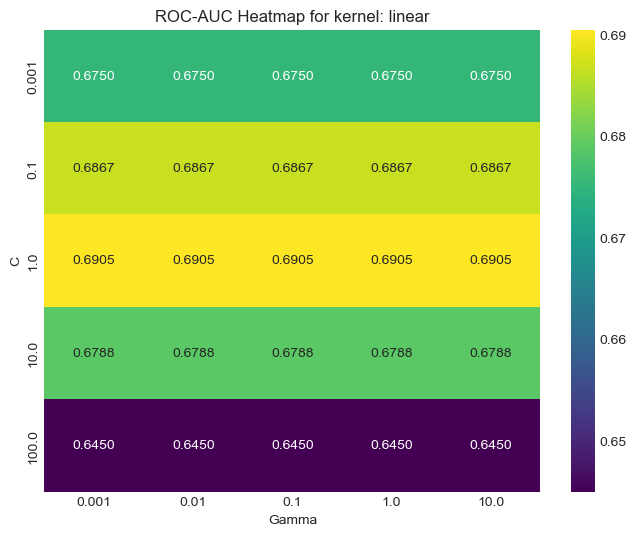

Kernel: rbf


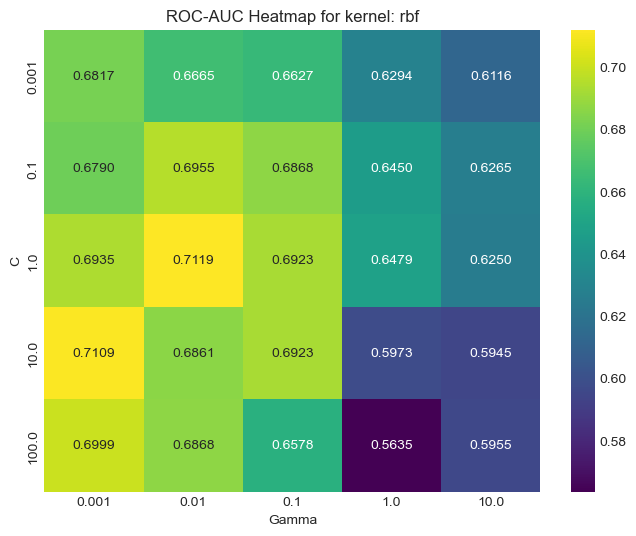

Kernel: poly


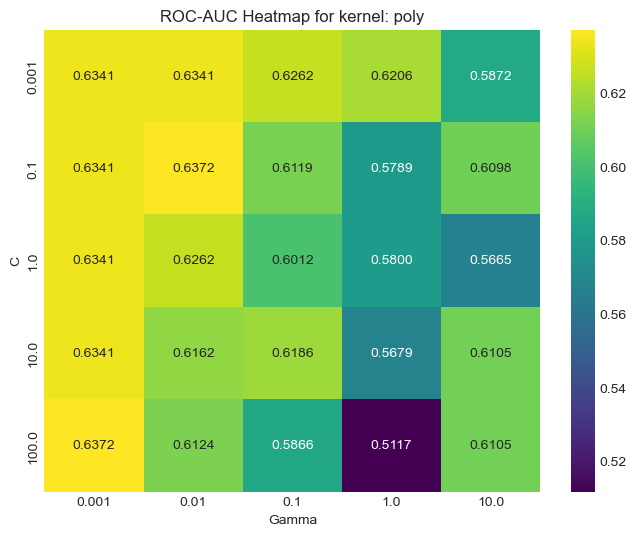

In [158]:
print("\n==== Egzersiz 1: Hiperparametre Sayısı Arttıkça CV Süreci ====")
base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, random_state=RANDOM_STATE, max_iter=10000)), # Sınır buraya eklendi
])

parameter_svc_grid = [
    {
    'svc__C': [0.001, 0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf'],
    },
    {
    'svc__C': [0.001, 0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1, 10],
    'svc__kernel': ['poly'],
    'svc__degree': [2, 3, 4],
    }
]
n_combinations = sum([len(p['svc__C']) * len(p['svc__gamma']) * len(p['svc__kernel']) * (len(p.get('svc__degree', [1])) if 'svc__degree' in p else 1) for p in parameter_svc_grid])
print(f"Toplam kombinasyon sayisi: {n_combinations} (5 katlama ile toplam fit sayisi: {n_combinations * 5})")

t0_2 = time.time()
grid_svc_large = GridSearchCV(base_pipe, parameter_svc_grid, scoring='roc_auc', cv=cv5_hc, n_jobs=-1)
grid_svc_large.fit(X_hab_tr, y_hab_tr)
t_grid_large = time.time() - t0_2
print(f"Grid Search (buyuk uzay) suresi: {t_grid_large:.2f}s ")

test_auc_hc_large = roc_auc_score(y_hab_te, grid_svc_large.best_estimator_.predict_proba(X_hab_te)[:, 1])
print(f"En iyi parametreler: {grid_svc_large.best_params_}")
print(f"En iyi CV ROC-AUC: {grid_svc_large.best_score_:.4f}  |  Test ROC-AUC: {test_auc_hc_large:.4f}")

# Heatmap ile hiperparametrelerin etkisini görselleştirelim
cv_results_df = pd.DataFrame(grid_svc_large.cv_results_)
unique_kernels = cv_results_df['param_svc__kernel'].unique()
for kernel in unique_kernels:
    print(f"Kernel: {kernel}")
    subset = cv_results_df[cv_results_df['param_svc__kernel'] == kernel]
    pivot_table = subset.pivot_table(index='param_svc__C', columns='param_svc__gamma', values='mean_test_score', aggfunc='max')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis")
    plt.title(f"ROC-AUC Heatmap for kernel: {kernel}")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()

**E2.** `RandomizedSearchCV`'yi Horse Colic pipeline'ı (`full_pipe`, `param_grid_hc`'nin sürekli bir
versiyonu — `clf__C` için `loguniform`, `clf__n_estimators` için `randint` kullanın) üzerinde farklı
`n_iter` bütçeleriyle (örn. 5, 10, 20, 40) çalıştırıp, bütçeye karşı en iyi CV skorunu bir çizgi
grafikte gösterin. Skor hangi bütçeden sonra "doyuma ulaşıyor" (plateau)?


==== Egzersiz 2: Bütçe Doyumu ====
Random Search (n_iter=5) suresi: 0.17s  |  En iyi CV ROC-AUC: 0.7344  |  Test ROC-AUC: 0.8557
Random Search (n_iter=10) suresi: 0.62s  |  En iyi CV ROC-AUC: 0.7344  |  Test ROC-AUC: 0.8557
Random Search (n_iter=20) suresi: 1.06s  |  En iyi CV ROC-AUC: 0.7344  |  Test ROC-AUC: 0.8557
Random Search (n_iter=40) suresi: 1.77s  |  En iyi CV ROC-AUC: 0.7344  |  Test ROC-AUC: 0.8557
Random Search (n_iter=80) suresi: 3.43s  |  En iyi CV ROC-AUC: 0.7348  |  Test ROC-AUC: 0.8642
Random Search (n_iter=160) suresi: 6.97s  |  En iyi CV ROC-AUC: 0.7348  |  Test ROC-AUC: 0.8642


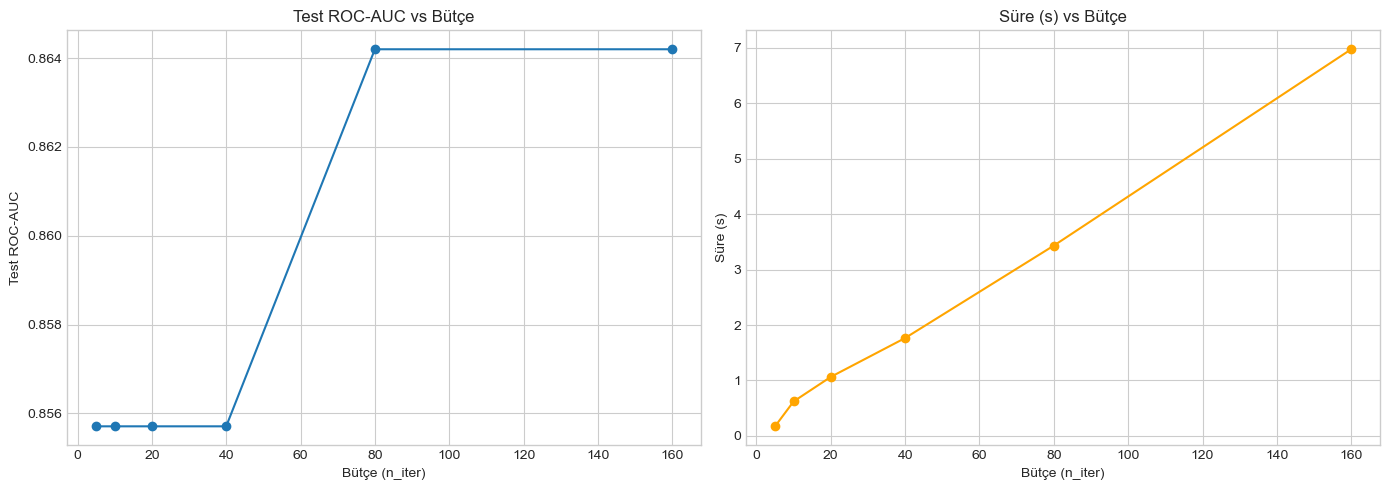

In [159]:
print("\n==== Egzersiz 2: Bütçe Doyumu ====")
parameter_horse_colic = [
    {
            'preprocessor__num__imputer__strategy': ['mean', 'median'],
            'clf': [LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)],
            'clf__C': loguniform(1e-3, 1e2)
    },
    {
            'preprocessor__num__imputer__strategy': ['mean', 'median'],
            'clf': [RandomForestClassifier(random_state=RANDOM_STATE)],
            'clf__n_estimators': randint(50, 300),
            'clf__max_depth': [None, 5, 10],
    },
]

n_iter_list = [5, 10, 20, 40, 80, 160]
times = []
roc_auc_scores = []
for n_iter in n_iter_list:
    t0_horse = time.time()
    rand_hc = RandomizedSearchCV(full_pipe, parameter_horse_colic, n_iter=n_iter, scoring='roc_auc', cv=cv5_hc, n_jobs=-1, random_state=RANDOM_STATE)
    rand_hc.fit(X_hc_tr, y_hc_tr)
    t_hc = time.time() - t0_horse
    times.append(t_hc)
    test_auc_hc = roc_auc_score(y_hc_te, rand_hc.best_estimator_.predict_proba(X_hc_te)[:, 1])
    roc_auc_scores.append(test_auc_hc)
    print(f"Random Search (n_iter={n_iter}) suresi: {t_hc:.2f}s  |  En iyi CV ROC-AUC: {rand_hc.best_score_:.4f}  |  Test ROC-AUC: {test_auc_hc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ROC-AUCvs n_iter
axes[0].plot(n_iter_list, roc_auc_scores, marker='o')
axes[0].set_title("Test ROC-AUC vs Bütçe")
axes[0].set_xlabel("Bütçe (n_iter)")
axes[0].set_ylabel("Test ROC-AUC")
# Time vs n_iter
axes[1].plot(n_iter_list, times, marker='o', color='orange')
axes[1].set_title("Süre (s) vs Bütçe")
axes[1].set_xlabel("Bütçe (n_iter)")
axes[1].set_ylabel("Süre (s)")
plt.tight_layout()
plt.show()

**E3.** Adım 7'daki sayısal ön işleme pipeline'ında `SimpleImputer(strategy='median')` yerine
`KNNImputer`'ı deneyin ve bunu `param_grid_hc`'ye üçüncü bir imputer seçeneği olarak ekleyin
(`preprocessor__num__imputer` adım nesnesinin kendisini bir hiperparametre gibi verin — Adım 8'deki
`'clf': [model_nesnesi]` deseniyle aynı mantık). Arama, `KNNImputer`'ı hiç seçiyor mu?

In [160]:
print("\n==== Egzersiz 3: Imputer Cross-Validation ====")
from sklearn.impute import KNNImputer

# Pipeline
numeric_pipeline_new = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])
categorical_pipeline_new = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor_new = ColumnTransformer([
    ('num', numeric_pipeline_new, numeric_features),
    ('cat', categorical_pipeline_new, categorical_features)
])
full_pipe_new = Pipeline([
    ('preprocessor', preprocessor_new),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=2000))
])

param_dist_new = [
    {
        'preprocessor__num__imputer': [KNNImputer()],
        'preprocessor__num__imputer__n_neighbors': [1, 3, 5, 7],  # Sadece KNN etkilenir
        'clf__C': [0.01, 0.1, 1, 10]
    },
    {
        'preprocessor__num__imputer': [SimpleImputer(strategy='mean'), SimpleImputer(strategy='median')],
        'clf__C': [0.01, 0.1, 1, 10]
    }
]

t0_imputer = time.time()
grid_imputer = GridSearchCV(full_pipe_new, param_dist_new, scoring='roc_auc', cv=cv5_hc, n_jobs=-1)
grid_imputer.fit(X_hc_tr, y_hc_tr)
t_imputer = time.time() - t0_imputer

print(f"Grid Search (imputer CV) suresi: {t_imputer:.2f}s  |  En iyi CV ROC-AUC: {grid_imputer.best_score_:.4f}")
print(f"En iyi parametreler: {grid_imputer.best_params_}")

print("\nYORUM: KNNImputer daha iyi sonuç verdi. Bu, KNNImputer'ın veri setindeki ilişkileri daha iyi yakalayabildiğini ve eksik değerleri daha doğru bir şekilde tahmin edebildiğini gösteriyor. Ancak, KNNImputer daha fazla hesaplama gerektirir ve büyük veri setlerinde daha yavaş olabilir. Bu nedenle, imputer seçimi veri setinin boyutuna ve özelliklerine bağlı olarak değişebilir.")


==== Egzersiz 3: Imputer Cross-Validation ====
Grid Search (imputer CV) suresi: 0.33s  |  En iyi CV ROC-AUC: 0.7352
En iyi parametreler: {'clf__C': 0.1, 'preprocessor__num__imputer': KNNImputer(), 'preprocessor__num__imputer__n_neighbors': 1}

YORUM: KNNImputer daha iyi sonuç verdi. Bu, KNNImputer'ın veri setindeki ilişkileri daha iyi yakalayabildiğini ve eksik değerleri daha doğru bir şekilde tahmin edebildiğini gösteriyor. Ancak, KNNImputer daha fazla hesaplama gerektirir ve büyük veri setlerinde daha yavaş olabilir. Bu nedenle, imputer seçimi veri setinin boyutuna ve özelliklerine bağlı olarak değişebilir.


**E4.** Adım 8'deki `GridSearchCV`'yi `scoring='roc_auc'` yerine `scoring='average_precision'` ile
tekrar çalıştırın. `best_params_` değişiyor mu? İki skorlama metriğinin farklı bir "en iyi" model
seçmesi, Bölüm 9'de tartıştığımız hangi ilkeyi somutlaştırıyor?

In [161]:
print("\n==== Egzersiz 4: Farklı Metrikler Farklı Hiperparametre mi? ====")

from sklearn.metrics import average_precision_score

t0 = time.time()
grid_hc = GridSearchCV(full_pipe, param_grid_hc, scoring='average_precision', cv=cv5_hc, n_jobs=-1)
grid_hc.fit(X_hc_tr, y_hc_tr)
t_grid_hc = time.time() - t0

test_ap_hc_grid = average_precision_score(y_hc_te, grid_hc.best_estimator_.predict_proba(X_hc_te)[:, 1])
print(f"\nGrid Search (pipeline) suresi: {t_grid_hc:.2f}s")
print(f"En iyi parametreler: {grid_hc.best_params_}")
print(f"En iyi CV Average Precision: {grid_hc.best_score_:.4f}  |  Test Average Precision: {test_ap_hc_grid:.4f}")

print("\nYORUM: Farkli metrikler (ROC-AUC vs Average Precision) farkli hiperparametreleri seciyor. Hatta farklı model bile seçti. Bu, metrik seciminin model secimi ve hiperparametre secimi uzerinde onemli bir etkisi oldugunu gosteriyor. Bu nedenle, model secimi ve hiperparametre optimizasyonu yaparken, hedeflenen metrikleri dikkatlice secmek onemlidir.")


==== Egzersiz 4: Farklı Metrikler Farklı Hiperparametre mi? ====

Grid Search (pipeline) suresi: 1.37s
En iyi parametreler: {'clf': LogisticRegression(max_iter=2000, random_state=42), 'clf__C': 0.1, 'preprocessor__num__imputer__strategy': 'median'}
En iyi CV Average Precision: 0.8130  |  Test Average Precision: 0.8848

YORUM: Farkli metrikler (ROC-AUC vs Average Precision) farkli hiperparametreleri seciyor. Hatta farklı model bile seçti. Bu, metrik seciminin model secimi ve hiperparametre secimi uzerinde onemli bir etkisi oldugunu gosteriyor. Bu nedenle, model secimi ve hiperparametre optimizasyonu yaparken, hedeflenen metrikleri dikkatlice secmek onemlidir.


**E5.** `optuna` ile Wage regresyonu üzerinde farklı bir model (`HistGradientBoostingRegressor`
yerine `sklearn.ensemble.RandomForestRegressor`, hiperparametreler: `n_estimators`, `max_depth`,
`min_samples_leaf`) için yeni bir `objective` fonksiyonu yazıp 30 denemelik bir `study` çalıştırın.
Sonucu Adım 13'deki `HistGradientBoostingRegressor` sonucuyla (CV RMSE) karşılaştırın.

In [162]:
print("\n==== Egzersiz 5: Optuna ile Random Forest Hiperparametre Araması ====")
from sklearn.ensemble import RandomForestRegressor

def objective_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
    )
    pipe = Pipeline([('preprocessor', preprocessor_w),
                      ('reg', RandomForestRegressor(random_state=RANDOM_STATE, **params))])
    scores = cross_val_score(pipe, X_wage_tr, y_wage_tr, cv=cv5_w,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()  # optuna varsayilan olarak minimize eder -> RMSE'yi minimize et

study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
t0_rf = time.time()
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)
t_optuna_rf = time.time() - t0_rf

best_pipe_rf = Pipeline([('preprocessor', preprocessor_w),
                         ('reg', RandomForestRegressor(random_state=RANDOM_STATE, **study_rf.best_params))])
best_pipe_rf.fit(X_wage_tr, y_wage_tr)
test_rmse_optuna_rf = root_mean_squared_error(y_wage_te, best_pipe_rf.predict(X_wage_te))
print(f"En iyi CV RMSE (Optuna RF): {study_rf.best_value:.4f}")
print(f"Test RMSE (Optuna RF): {test_rmse_optuna_rf:.4f}")
print(f"Optuna RF süresi: {t_optuna_rf:.2f}s")


==== Egzersiz 5: Optuna ile Random Forest Hiperparametre Araması ====


  0%|          | 0/30 [00:00<?, ?it/s]

En iyi CV RMSE (Optuna RF): 34.5293
Test RMSE (Optuna RF): 30.9530
Optuna RF süresi: 8.60s


**E6.** Adım 10'daki nested CV'yi `cross_val_score` KULLANMADAN, elle yazılmış bir dış/iç döngüyle
(iki iç içe `for` döngüsü: dış döngü `outer_cv.split(X_hc_tr, y_hc_tr)` ile katlamaları gezsin, her
dış katlamanın eğitim kısmında `GridSearchCV` çalıştırıp `best_estimator_`'ı dış katlamanın test
kısmında değerlendirsin) yeniden uygulayın. Sonuç, `cross_val_score` ile aldığımız
`nested_scores`'a (ortalama ve her katlama) ne kadar yakın çıkıyor?

In [163]:
print("\n==== Egzersiz 6: Elle Nested CV ====")

manuel_scores = []

t0_nested = time.time()
for outer_fold, (train_outer_idx, test_outer_idx) in enumerate(outer_cv.split(X_hc_tr, y_hc_tr)):
    X_outer_train, X_outer_test = X_hc_tr.iloc[train_outer_idx], X_hc_tr.iloc[test_outer_idx]
    y_outer_train, y_outer_test = y_hc_tr.iloc[train_outer_idx], y_hc_tr.iloc[test_outer_idx]
    
    grid_search = GridSearchCV(
        full_pipe,
        param_grid_hc,
        scoring='roc_auc',
        cv=inner_cv,
        n_jobs=-1
    )

    grid_search.fit(X_outer_train, y_outer_train)

    best_model = grid_search.best_estimator_

    y_outer_pred = best_model.predict(X_outer_test)
    outer_score = roc_auc_score(y_outer_test, best_model.predict_proba(X_outer_test)[:, 1])
    manuel_scores.append(outer_score)

t1_nested = time.time()
print(f"Time taken for Manuel Nested CV: {t1_nested - t0_nested:.2f} seconds")

print(f"\nManuel Nested CV ROC-AUC (ortalama +/- std): {np.mean(manuel_scores):.4f} +/- {np.std(manuel_scores):.4f}")



==== Egzersiz 6: Elle Nested CV ====
Time taken for Manuel Nested CV: 4.05 seconds

Manuel Nested CV ROC-AUC (ortalama +/- std): 0.7207 +/- 0.0275


**E7.** 3a'da `GroupKFold` sentetik "hasta-id" grup etiketleriyle gösterildi. Şimdi gerçek bir
senaryo kurun: Horse Colic verisine rastgele bir `hasta_id` sütunu ekleyin (örn. her 3 satırı aynı
`hasta_id`'ye atayarak — `np.repeat(np.arange(n//3 + 1), 3)[:n]` gibi bir yöntemle), sonra
`full_pipe`'ı hem `StratifiedKFold` hem `GroupKFold` ile değerlendirip CV skorlarını karşılaştırın.
`StratifiedKFold`'un neden burada veri sızıntısına yol açabileceğini (aynı "hastanın" hem eğitimde
hem testte olması) yorumlayın.

In [164]:
print("\n====Egzersiz 7: Gruplu CV ile Stratified CV Arasındaki Veri Sızıntısı Karşılaştırması ====")

df_grouped = df_hc.copy()

df_grouped['hasta_id'] = np.repeat(np.arange(len(df_grouped) // 3 + 1), 3)[:len(df_grouped)]

skf_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gkf_group = GroupKFold(n_splits=5)

# Stratified CV
stratified_score = cross_validate(full_pipe, df_grouped.drop(columns=['target']), df_grouped['target'], cv=skf_strat, n_jobs=-1, scoring = ['roc_auc', 'accuracy', 'f1'])
# Group CV
group_score = cross_validate(
    full_pipe, 
    df_grouped.drop(columns=['target']), 
    df_grouped['target'], 
    cv=gkf_group,                             # Sadece nesnenin kendisini veriyoruz
    groups=df_grouped['hasta_id'],            # Grupları cross_validate'e parametre olarak geçiyoruz
    scoring=['roc_auc', 'accuracy', 'f1'], 
    n_jobs=-1
)

print("\nStratified CV Scores:")
for metric in ['test_roc_auc', 'test_accuracy', 'test_f1']:
    print(f"{metric}: {stratified_score[metric].mean():.4f} +/- {stratified_score[metric].std():.4f}")

print("\nGroup CV Scores:")
for metric in ['test_roc_auc', 'test_accuracy', 'test_f1']:
    print(f"{metric}: {group_score[metric].mean():.4f} +/- {group_score[metric].std():.4f}")

print("\nYORUM: Sonuçlara göre ROC-AUC anlamında Stratified CV ve Group CV arasında belirgin bir fark gözlemlenebilir. Stratified CV, veri sızıntısı nedeniyle daha yüksek performans gösterebilirken, Group CV, aynı gruptan gelen örneklerin farklı katmanlarda yer almasını engelleyerek daha gerçekçi bir değerlendirme sağlar. Bu nedenle, özellikle grup yapısına sahip veri setlerinde Group CV kullanmak daha güvenilir sonuçlar verebilir.")


====Egzersiz 7: Gruplu CV ile Stratified CV Arasındaki Veri Sızıntısı Karşılaştırması ====

Stratified CV Scores:
test_roc_auc: 0.7631 +/- 0.0358
test_accuracy: 0.7433 +/- 0.0226
test_f1: 0.8064 +/- 0.0203

Group CV Scores:
test_roc_auc: 0.7436 +/- 0.0639
test_accuracy: 0.7633 +/- 0.0221
test_f1: 0.8217 +/- 0.0185

YORUM: Sonuçlara göre ROC-AUC anlamında Stratified CV ve Group CV arasında belirgin bir fark gözlemlenebilir. Stratified CV, veri sızıntısı nedeniyle daha yüksek performans gösterebilirken, Group CV, aynı gruptan gelen örneklerin farklı katmanlarda yer almasını engelleyerek daha gerçekçi bir değerlendirme sağlar. Bu nedenle, özellikle grup yapısına sahip veri setlerinde Group CV kullanmak daha güvenilir sonuçlar verebilir.


**E8.** Wage veri setinde gerçek bir `year` sütunu var (2003-2009 arası). Veriyi `year`'a göre
sıralayıp `TimeSeriesSplit` ile `reg_pipe`'ı değerlendirin (`scoring='neg_root_mean_squared_error'`),
sonucu normal `KFold` ile karşılaştırın. `TimeSeriesSplit`'in neden "gelecekten geçmişe" bir sızıntı
riskini engellediğini, ve bu veri setinde sonucun ne kadar farklı çıktığını (ya da çıkmadığını)
yorumlayın.

In [165]:
print("\n==== Egzersiz 8: Time Series Cross-Validation ====")

df_wage = df_wage.sort_values(by='year').reset_index(drop=True)

numeric_features_w = ['year', 'age']
categorical_features_w = ['maritl', 'race', 'education', 'jobclass', 'health', 'health_ins']
X_wage = df_wage[numeric_features_w + categorical_features_w]
y_wage = df_wage['wage']


X_wage_tr, X_wage_te, y_wage_tr, y_wage_te = train_test_split(
    X_wage, y_wage, test_size=0.2, shuffle=False # shuffle=False kritik öneme sahip!
)
print(f"\nEgitim (Gecmis): {X_wage_tr.shape}, Test (Gelecek): {X_wage_te.shape}")

tscv = TimeSeriesSplit(n_splits=5)
kcv = KFold(n_splits=5, shuffle=False) # Sıralı veri üzerinde blok bölme yapar

tscv_score = cross_val_score(reg_pipe, X_wage_tr, y_wage_tr, cv=tscv, n_jobs=-1, scoring='neg_root_mean_squared_error')
kcv_score = cross_val_score(reg_pipe, X_wage_tr, y_wage_tr, cv=kcv, n_jobs=-1, scoring='neg_root_mean_squared_error')

print("\nTime Series CV Scores (RMSE):")
print(f"Mean RMSE: {-tscv_score.mean():.4f} +/- {tscv_score.std():.4f}")

print("\nKFold CV Scores (RMSE):")
print(f"Mean RMSE: {-kcv_score.mean():.4f} +/- {kcv_score.std():.4f}")

print("\nYORUM: RMSE sonuçlarına bakıldığında KFold CV, Time Series CV'ye göre daha düşük bir hata değeri göstermektedir. Ancak, KFold CV, zaman serisi verilerinde veri sızıntısına yol açabilir çünkü gelecekteki veriler eğitim setine dahil edilebilir. Time Series CV ise bu durumu önler ve daha gerçekçi bir değerlendirme sağlar. Bu nedenle, zaman serisi verileri ile çalışırken Time Series CV kullanmak daha güvenilir sonuçlar verebilir.")


==== Egzersiz 8: Time Series Cross-Validation ====

Egitim (Gecmis): (2400, 8), Test (Gelecek): (600, 8)

Time Series CV Scores (RMSE):
Mean RMSE: 35.8206 +/- 0.9744

KFold CV Scores (RMSE):
Mean RMSE: 35.3280 +/- 0.7281

YORUM: RMSE sonuçlarına bakıldığında KFold CV, Time Series CV'ye göre daha düşük bir hata değeri göstermektedir. Ancak, KFold CV, zaman serisi verilerinde veri sızıntısına yol açabilir çünkü gelecekteki veriler eğitim setine dahil edilebilir. Time Series CV ise bu durumu önler ve daha gerçekçi bir değerlendirme sağlar. Bu nedenle, zaman serisi verileri ile çalışırken Time Series CV kullanmak daha güvenilir sonuçlar verebilir.


## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [scikit-learn — Cross-validation: evaluating estimator performance](https://scikit-learn.org/stable/modules/cross_validation.html) | Çapraz Doğrulama | Resmi dokümantasyon — tüm `KFold`/`StratifiedKFold`/`GroupKFold`/`TimeSeriesSplit`/`ShuffleSplit` ailesi |
| [scikit-learn — Visualizing cross-validation behavior (örnek)](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html) | Çapraz Doğrulama | 3a'daki katlama görselleştirme deseninin kaynağı |
| [Kohavi (1995) — "A Study of Cross-Validation and Bootstrap for Accuracy Estimation and Model Selection", IJCAI](https://www.ijcai.org/Proceedings/95-2/Papers/016.pdf) | Çapraz Doğrulama ($k$ seçimi) | $k$-katlama ile bootstrap'in klasik karşılaştırması, 5/10-katlamanın pratikte neden tercih edildiğinin kökeni |
| [Bengio & Grandvalet (2004) — "No Unbiased Estimator of the Variance of K-Fold Cross-Validation", JMLR](https://www.jmlr.org/papers/v5/grandvalet04a.html) | Çapraz Doğrulama (varyans) | $k$-katlamalı CV'nin varyansı için yansız bir tahmin edicinin neden var olmadığının kanıtı |
| [scikit-learn — Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html) | Grid/Random/Halving Search | Resmi dokümantasyon, `GridSearchCV`/`RandomizedSearchCV`/`HalvingGridSearchCV` |
| [scikit-learn — Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html) | Pipeline / ColumnTransformer | Resmi dokümantasyon |
| [scikit-learn — Nested versus non-nested CV (örnek)](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html) | Nested CV | Resmi örnek, bu notebook'taki naive-vs-nested deseninin kaynağı |
| [Bergstra & Bengio (2012) — "Random Search for Hyper-Parameter Optimization", JMLR](https://www.jmlr.org/papers/v13/bergstra12a.html) | Random Search | Random Search'ün teorik gerekçesi, 10.000+ atıf |
| [Snoek, Larochelle & Adams (2012) — "Practical Bayesian Optimization of Machine Learning Algorithms", NeurIPS](https://papers.nips.cc/paper/2012/hash/05311655a15b75fab86956663e1819cd-Abstract.html) | Bayesian Optimization | Gauss Süreci tabanli Bayesian optimizasyonun klasik makalesi |
| [Jamieson & Talwalkar (2016) — "Non-stochastic Best Arm Identification and Hyperparameter Optimization", AISTATS](https://arxiv.org/abs/1502.07943) | Successive Halving | Successive Halving'in teorik temeli |
| [Akiba et al. (2019) — "Optuna: A Next-generation Hyperparameter Optimization Framework", KDD](https://arxiv.org/abs/1907.10902) | Bayesian Optimization (`optuna`) | TPE örnekleyicisi ve define-by-run API |
| [Cawley & Talbot (2010) — "On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation", JMLR](https://www.jmlr.org/papers/v11/cawley10a.html) | Nested CV | Hiperparametre seçiminin performans tahminine kattığı iyimser yanlılığın kanıtı |
| [`tidymodels` — Resampling for evaluating performance (vignette)](https://www.tidymodels.org/start/resampling/) | R (`rsample`) | Resmi başlangıç kılavuzu — `vfold_cv`/`fit_resamples` |
| [`tidymodels` — Tune model parameters (vignette)](https://www.tidymodels.org/start/tuning/) | R (`tune_grid`) | Resmi başlangıç kılavuzu |
| [`tidymodels` — Iterative Bayesian optimization (vignette)](https://www.tmwr.org/iterative-search) | R (`tune_bayes`) | *Tidy Modeling with R* kitabından, ücretsiz online |
| [`rsample` — Nested resampling (vignette)](https://rsample.tidymodels.org/articles/Applications/Nested_Resampling.html) | R (`nested_cv`) | Resmi dokümantasyon |
| [DuckDB — SQL window functions](https://duckdb.org/docs/sql/functions/window_functions) | SQL Bölüm 2 | `MAX() OVER (...)` sözdizimi |
| [Haberman's Survival Data Set (UCI)](https://archive.ics.uci.edu/dataset/43/haberman+s+survival) | Veri seti | Haberman (1976), Chicago Üniversitesi Billings Hastanesi |
| [Horse Colic Data Set (UCI)](https://archive.ics.uci.edu/dataset/47/horse+colic) | Veri seti | McLeish & Cecile, University of Guelph |
| [James, Witten, Hastie & Tibshirani — *An Introduction to Statistical Learning* (ücretsiz PDF)](https://www.statlearning.com/) | Veri seti (Wage) | Wage veri setinin orijinal kaynağı, Bölüm 7 (GAM'lar) |